# Population-model training analysis

Reads the output of `ProVoice.training_scripts.run_population_pipeline` — four sweeps,
each in its own directory:

| section | stage | loss | window | grid |
|---|---|---|---|---|
| 1 | `corn_w10` | soft-CORN | 10 s | full (3 dropout x 2 lr) |
| 2 | `ce_w10`   | softmax/CE | 10 s | full |
| 3 | `corn_w5`  | soft-CORN | 5 s  | winner of stage 1 |
| 4 | `corn_w20` | soft-CORN | 20 s | winner of stage 1 |

Every section produces the same eight things, so the stages stay comparable:

1. **Per-configuration** table — set-MAE / set-accuracy averaged over folds and seeds.
2. **Per-configuration x validation-fold** table — the same, broken out by fold.
3. **Early-win table** — how often an epoch below `--min-select-epoch` would have won.
4. **Init vs best vs constant** — does training achieve anything, and does it beat a constant?
5. **Variance decomposition** — can this sweep resolve configurations at all?
6. **Paired configuration comparison** — config deltas with fold difficulty cancelled.
7. **Distribution-distance tables** — earth-mover's distance between the prediction,
   train-label and validation-label shapes over LoA: per configuration x fold (7),
   then averaged over every run in the stage (7b).
8. **Histograms and validation curves.**

Stages with a single configuration (3 and 4) use the identical format, just with one row.

**Two reference lines recur and both matter:**

* the **constant floor** — best set-MAE reachable by always predicting one fixed LoA
  (~1.32 globally on this cohort). A model above it is losing to "always say 1".
* the **untrained init** — the model before a single gradient step. Beating *this* is
  "training did something"; beating the *floor* is "what it did generalizes". Those are
  different claims and the tables below keep them apart.

In [41]:
import sys, pathlib, warnings, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon
from IPython.display import display, Markdown

# The notebook lives in src/ProVoice/training_analysis/; walk up to find src/.
_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, not re-implemented: anything recomputed from the curves must use the
# SAME smoothing the sweep used, or it answers a different question.
from ProVoice.training_scripts.sweep_population_hparams import smooth, SMOOTH_WINDOW

%matplotlib inline
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------- configuration
BASE = pathlib.Path("../../../results/pop_pipeline")   # the pipeline's --outdir
MIN_SELECT_EPOCH = 3      # must match the value the sweep ran with
LOA = [0, 1, 2, 3, 4]

STAGES = [
    ("corn_w10", "1. Full grid — soft-CORN, 10 s window"),
    ("ce_w10",   "2. Softmax / cross-entropy ablation — 10 s window"),
    ("corn_w5",  "3. 5 s window — soft-CORN, winning configuration"),
    ("corn_w20", "4. 20 s window — soft-CORN, winning configuration"),
]
print(f"BASE = {BASE.resolve()}")
for name, _ in STAGES:
    p = BASE / name / "sweep_results.csv"
    n = (sum(1 for _ in p.open()) - 1) if p.exists() else 0
    print(f"  {name:<10} {'found' if p.exists() else 'MISSING':<8} {n:>4} rows")

BASE = C:\Users\markc\Documents\ProActivity_Personalization\results\pop_pipeline
  corn_w10   found     180 rows
  ce_w10     found     180 rows
  corn_w5    found     180 rows
  corn_w20   found     180 rows


In [42]:
# ------------------------------------------------------------------- loading

def load_stage(name: str) -> pd.DataFrame:
    """One stage's sweep_results.csv, or an empty frame if it has not run."""
    p = BASE / name / "sweep_results.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    # window/loss are constant within a stage, so the configuration IS (dropout, lr).
    df["config"] = ("drop=" + df["dropout"].astype(str)
                    + " lr=" + df["lr"].map(lambda x: f"{x:g}"))
    return df


def load_curves(name: str) -> pd.DataFrame:
    """Every per-epoch curve for a stage, tagged by its filename."""
    d = BASE / name / "runs"
    if not d.exists():
        return pd.DataFrame()
    out = []
    for f in sorted(d.glob("metrics_*.csv")):
        try:
            c = pd.read_csv(f)
        except Exception:
            continue
        if c.empty:
            continue
        c["tag"] = f.stem[len("metrics_"):]
        out.append(c)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def _config_from_tag(tag: str):
    """(config label, dropout, lr, fold) from a run tag `d0.15_lr0.002_f001-005_s0_w10_corn`."""
    try:
        drop = float(tag.split("_lr")[0][1:])
        rest = tag.split("_lr")[1]
        lr = float(rest.split("_f")[0])
        fold = rest.split("_f")[1].split("_s")[0].replace("-", "|")
        return f"drop={drop} lr={lr:g}", drop, lr, fold
    except Exception:
        return "?", np.nan, np.nan, "?"


def per_run_curves(name: str, min_select_epoch: int = MIN_SELECT_EPOCH) -> pd.DataFrame:
    """One row per RUN, derived from its retained per-epoch curve.

    The shared source for the early-win and init-vs-best tables — both need the
    curve, not the summary CSV, because the summary only records the FLOORED
    selection and never records the untrained init.
    """
    curves = load_curves(name)
    if curves.empty:
        return pd.DataFrame()
    rows = []
    for tag, c in curves.groupby("tag"):
        c = c.sort_values("epoch")
        mae = c["set_mae"].to_numpy(dtype=float)
        if len(mae) == 0:
            continue
        sm = smooth(mae, SMOOTH_WINDOW)
        j_free = int(np.argmin(sm))                        # no floor
        lo = min(int(min_select_epoch), len(sm) - 1)
        j_sel = lo + int(np.argmin(sm[lo:]))               # as the sweep selects
        cfg, drop, lr, fold = _config_from_tag(tag)

        def col(nm, default=np.nan):
            return float(c[nm].iloc[0]) if nm in c.columns and pd.notna(c[nm].iloc[0]) else default

        rows.append({
            "tag": tag, "config": cfg, "dropout": drop, "lr": lr, "val_pids": fold,
            "epochs_run": len(mae),
            "epoch_unfloored": int(c["epoch"].iloc[j_free]),
            "epoch_selected": int(c["epoch"].iloc[j_sel]),
            "mae_unfloored": float(sm[j_free]),
            "mae_selected": float(sm[j_sel]),
            "acc_selected": float(c["set_acc"].iloc[j_sel]),
            "init_mae": col("init_set_mae"), "init_acc": col("init_set_acc"),
            "const_mae": col("const_set_mae"), "const_acc": col("const_set_acc"),
        })
    return pd.DataFrame(rows)


def _fmt(df: pd.DataFrame, cols) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df:
            df[c] = df[c].astype(float).round(3)
    return df

In [43]:
# ---------------------------------------------------------- tables 1 and 2

def table_per_config(df: pd.DataFrame) -> pd.DataFrame:
    """set-MAE / set-accuracy per configuration, averaged over folds and seeds.

    `set_mae` is `smoothed_best_set_mae` — what the sweep RANKS on — not the raw
    per-epoch minimum, which is optimistically biased by minimising over ~100
    noisy epochs. `mae_raw` keeps that minimum alongside so the gap is visible.

    `vs_const` is the number to read: negative beats a constant prediction,
    positive does not.
    """
    if df.empty:
        return pd.DataFrame()
    g = df.groupby("config", as_index=False).agg(
        n_runs=("seed", "size"),
        set_mae=("smoothed_best_set_mae", "mean"),
        mae_sd=("smoothed_best_set_mae", "std"),
        mae_raw=("best_set_mae", "mean"),
        set_acc=("set_acc_at_best", "mean"),
        acc_sd=("set_acc_at_best", "std"),
        qwk=("qwk_at_best", "mean"),
        const_mae=("const_set_mae", "mean"),
        const_acc=("const_set_acc", "mean"),
        E_star=("best_epoch_1se", "median"),
    )
    g["mae_se"] = g["mae_sd"] / np.sqrt(g["n_runs"].clip(lower=1))
    g["vs_const"] = g["set_mae"] - g["const_mae"]
    g["beats_const"] = g["vs_const"] < 0
    cols = ["config", "n_runs", "set_mae", "mae_sd", "mae_se", "mae_raw",
            "set_acc", "acc_sd", "qwk", "const_mae", "const_acc",
            "vs_const", "beats_const", "E_star"]
    return _fmt(g[cols].sort_values("set_mae").reset_index(drop=True),
                ["set_mae", "mae_sd", "mae_se", "mae_raw", "set_acc", "acc_sd",
                 "qwk", "const_mae", "const_acc", "vs_const"])


def table_per_config_fold(df: pd.DataFrame) -> pd.DataFrame:
    """The same metrics broken out by configuration x validation fold.

    Where fold heterogeneity becomes visible: constant floors range ~0.54 to ~1.47
    across folds, so a configuration's mean hides which folds it actually failed on.
    """
    if df.empty:
        return pd.DataFrame()
    g = df.groupby(["config", "val_pids"], as_index=False).agg(
        n_seeds=("seed", "size"),
        set_mae=("smoothed_best_set_mae", "mean"),
        mae_sd=("smoothed_best_set_mae", "std"),
        set_acc=("set_acc_at_best", "mean"),
        acc_sd=("set_acc_at_best", "std"),
        const_mae=("const_set_mae", "mean"),
        const_acc=("const_set_acc", "mean"),
        val_n=("val_n", "mean"),
        E_star=("best_epoch_1se", "median"),
    )
    g["vs_const"] = g["set_mae"] - g["const_mae"]
    g["beats_const"] = g["vs_const"] < 0
    return _fmt(g.sort_values(["config", "val_pids"]).reset_index(drop=True),
                ["set_mae", "mae_sd", "set_acc", "acc_sd", "const_mae",
                 "const_acc", "vs_const"])

In [44]:
# ------------------------------ table 3: early wins, table 4: init vs best

def table_early_wins(pr: pd.DataFrame,
                     min_select_epoch: int = MIN_SELECT_EPOCH) -> pd.DataFrame:
    """How often an epoch BELOW the floor would have won, and what the floor cost.

    `--min-select-epoch` blocks early epochs from being checkpointed: epochs
    inside the LR warmup are not comparable to full-LR ones, and an unconstrained
    argmin of epoch 0 makes E*=0 — which would make the LODO runner train for
    zero epochs and ship random inits as population models.

    This says whether the floor is PROTECTING or BINDING:

    * `pct_early` — share of runs whose unfloored smoothed argmin was < the floor.
      High means held-out performance peaks before the model has trained, i.e.
      training hurts transfer from the start.
    * `mae_cost` — mean (selected - unfloored) over those runs: what the floor
      gave up. Compare against `mae_se` in table 1; below ~1 SE it is noise.
    """
    if pr.empty:
        return pd.DataFrame()
    pr = pr.copy()
    pr["early"] = pr["epoch_unfloored"] < min_select_epoch
    pr["cost"] = pr["mae_selected"] - pr["mae_unfloored"]
    g = pr.groupby("config", as_index=False).agg(
        n_runs=("early", "size"), n_early=("early", "sum"),
        median_epoch_unfloored=("epoch_unfloored", "median"),
        median_epoch_selected=("epoch_selected", "median"))
    cost = (pr[pr["early"]].groupby("config", as_index=False)["cost"]
            .mean().rename(columns={"cost": "mae_cost"}))
    g = g.merge(cost, on="config", how="left")
    g["pct_early"] = (100 * g["n_early"] / g["n_runs"]).round(1)
    g = g[["config", "n_runs", "n_early", "pct_early", "mae_cost",
           "median_epoch_unfloored", "median_epoch_selected"]]
    return _fmt(g.sort_values("pct_early", ascending=False).reset_index(drop=True),
                ["mae_cost"])


def table_init_vs_best(pr: pd.DataFrame) -> pd.DataFrame:
    """Untrained init -> selected model -> constant floor, per configuration.

    Separates two diagnoses the summary tables conflate:

    * `gain_vs_init` = selected - init. NEGATIVE means training achieved
      something. If it is ~0, the model learned nothing and every other number
      here is describing a random initialization.
    * `vs_const` = selected - constant floor. NEGATIVE means what it learned
      generalizes to held-out drivers.

    The interesting case on this cohort is `gain_vs_init < 0 < vs_const`:
    training works and still loses to "always predict one level", because driver
    preference does not transfer. `verdict` names which case each row is in.
    """
    if pr.empty or pr["init_mae"].isna().all():
        return pd.DataFrame()
    g = pr.groupby("config", as_index=False).agg(
        n_runs=("tag", "size"),
        init_mae=("init_mae", "mean"), init_acc=("init_acc", "mean"),
        best_mae=("mae_selected", "mean"), best_acc=("acc_selected", "mean"),
        const_mae=("const_mae", "mean"), const_acc=("const_acc", "mean"))
    g["gain_vs_init"] = g["best_mae"] - g["init_mae"]
    g["vs_const"] = g["best_mae"] - g["const_mae"]

    def verdict(r):
        learned, generalizes = r["gain_vs_init"] < -0.02, r["vs_const"] < 0
        if learned and generalizes:
            return "learns AND beats constant"
        if learned:
            return "learns, does NOT transfer"
        if generalizes:
            return "beats constant without learning (?)"
        return "no learning, no transfer"

    g["verdict"] = g.apply(verdict, axis=1)
    cols = ["config", "n_runs", "init_mae", "best_mae", "const_mae",
            "gain_vs_init", "vs_const", "init_acc", "best_acc", "const_acc", "verdict"]
    return _fmt(g[cols].sort_values("best_mae").reset_index(drop=True),
                [c for c in cols if c not in ("config", "n_runs", "verdict")])

In [45]:
# ---------------- table 5: variance decomposition, table 6: paired comparison

def table_variance(df: pd.DataFrame) -> pd.DataFrame:
    """Is this sweep able to resolve configurations at all?

    A go/no-go check, not a description. Three sources of spread in
    `smoothed_best_set_mae`:

    * **fold** — SD of the fold means. Expected to dominate: folds differ in
      intrinsic difficulty (constant floors ~0.54 to ~1.47), and that is a
      property of the drivers, not of any configuration.
    * **seed** — mean within-(config, fold) SD across seeds. The noise floor of a
      single run.
    * **config** — SD of the configuration means, and their max-min spread. This
      is the signal the sweep exists to measure.

    The verdict compares the configuration SPREAD against the standard error of
    a configuration mean (seed SD / sqrt(runs per config)). If the spread is
    below ~2 SE the ranking is not resolvable, and picking a winner is picking
    noise — in which case take the most regularized configuration (the sweep's
    own tie-break) and spend the compute elsewhere.
    """
    if df.empty:
        return pd.DataFrame()
    m = "smoothed_best_set_mae"
    n_cfg = df["config"].nunique()
    per_cfg = df.groupby("config")[m].mean()
    fold_sd = float(df.groupby("val_pids")[m].mean().std(ddof=1)) if df["val_pids"].nunique() > 1 else np.nan
    seed_sd = float(df.groupby(["config", "val_pids"])[m].std(ddof=1).mean())
    cfg_sd = float(per_cfg.std(ddof=1)) if n_cfg > 1 else np.nan
    cfg_spread = float(per_cfg.max() - per_cfg.min()) if n_cfg > 1 else np.nan
    n_per_cfg = float(df.groupby("config").size().mean())
    cfg_se = seed_sd / np.sqrt(max(n_per_cfg, 1.0))
    if n_cfg <= 1:
        verdict = "single configuration — nothing to resolve"
    elif not np.isfinite(cfg_spread) or not np.isfinite(cfg_se) or cfg_se == 0:
        verdict = "insufficient data"
    elif cfg_spread > 2 * cfg_se:
        verdict = f"RESOLVABLE (spread {cfg_spread:.3f} > 2 SE = {2 * cfg_se:.3f})"
    else:
        verdict = (f"NOT RESOLVABLE (spread {cfg_spread:.3f} <= 2 SE = {2 * cfg_se:.3f}) "
                   "— take the most regularized config")
    return pd.DataFrame([{
        "n_configs": n_cfg, "runs_per_config": round(n_per_cfg, 1),
        "fold_sd": round(fold_sd, 3) if np.isfinite(fold_sd) else np.nan,
        "seed_sd": round(seed_sd, 3),
        "config_sd": round(cfg_sd, 3) if np.isfinite(cfg_sd) else np.nan,
        "config_spread": round(cfg_spread, 3) if np.isfinite(cfg_spread) else np.nan,
        "config_mean_se": round(cfg_se, 3),
        "verdict": verdict}])


def table_paired_configs(df: pd.DataFrame) -> pd.DataFrame:
    """Every configuration against the best one, PAIRED on (fold, seed).

    Comparing configuration means across folds throws the pairing away, and fold
    difficulty dominates the variance — so an unpaired comparison can call a real
    difference a tie. Every configuration here saw the identical (fold, seed)
    cells, so differencing within a cell cancels fold difficulty exactly and
    leaves only the configuration effect.

    `delta` is (this config - reference); POSITIVE means worse than the
    reference. `t` is the paired t-statistic; |t| > ~2 with n cells is a
    difference the sweep can actually see. Reported as a descriptive statistic,
    NOT a hypothesis test — no multiplicity correction is applied and the cells
    are not independent across folds.
    """
    if df.empty or df["config"].nunique() < 2:
        return pd.DataFrame()
    m = "smoothed_best_set_mae"
    wide = df.pivot_table(index=["val_pids", "seed"], columns="config", values=m)
    ref = wide.mean().idxmin()
    rows = []
    for cfg in wide.columns:
        if cfg == ref:
            continue
        d = (wide[cfg] - wide[ref]).dropna()
        if d.empty:
            continue
        sd = float(d.std(ddof=1)) if len(d) > 1 else np.nan
        se = sd / np.sqrt(len(d)) if np.isfinite(sd) and len(d) else np.nan
        rows.append({"config": cfg, "vs_reference": ref, "n_pairs": int(len(d)),
                     "delta": float(d.mean()), "delta_sd": sd, "delta_se": se,
                     "t": float(d.mean() / se) if se and np.isfinite(se) and se > 0 else np.nan,
                     "worse_than_ref": bool(d.mean() > 0)})
    out = pd.DataFrame(rows)
    return _fmt(out.sort_values("delta").reset_index(drop=True),
                ["delta", "delta_sd", "delta_se", "t"]) if not out.empty else out

In [46]:
# ------------------------------------------------------------------- plots

def _loa_shares(row, cols):
    """A row's `*_loa{k}` counts as a probability vector over LOA, in LOA order.

    Shared by `plot_histograms` and `table_distribution_distance` so the two
    views of the same three-way comparison can't drift apart.
    """
    v = np.array([float(row[c]) for c in cols], dtype=float)
    t = v.sum()
    return v / t if t > 0 else v


def plot_val_curves(name: str, title: str):
    """Validation curves vs epoch — set-MAE (top row) and set-accuracy (bottom).

    **Left column** plots each metric MINUS that fold's own constant floor,
    averaged over folds and seeds, one line per configuration. Plotting raw
    values would be misleading: folds differ in difficulty by ~0.9 MAE, so an
    average across them mixes levels and the shape would be dominated by which
    folds a configuration happened to run. On these axes **y = 0 is the constant
    baseline**.

    **The two rows have OPPOSITE good directions** and the axis labels say so:
    for set-MAE lower is better, so below zero beats the floor; for
    set-accuracy higher is better, so above zero beats it. The floors are also
    two different predictors — the MAE-optimal constant and the
    accuracy-optimal constant are usually different LoAs (`const_loa_mae` vs
    `const_loa_acc`), which is why each row uses its own.

    **Right column** takes the best configuration and shows one raw line per
    fold, with that fold's floor as a matching dotted line. The spread between
    folds is the driver heterogeneity everything else here is about. Both rows
    use the SAME configuration — chosen on MAE, the design's selection metric —
    so the two views describe one model, not two.

    The dashed grey line is the untrained init; the vertical line is
    `--min-select-epoch`. A curve starting past the floor and moving away from
    it is a model whose held-out performance is degraded by training; a genuine
    interior optimum is one worth selecting an epoch from.
    """
    curves = load_curves(name)
    if curves.empty:
        print("(no per-epoch curves in runs/)")
        return
    need = {"const_set_mae", "const_set_acc", "set_acc"}
    if not need.issubset(curves.columns):
        print(f"(curves lack {sorted(need - set(curves.columns))} — re-run the sweep)")
        return
    meta = curves["tag"].map(_config_from_tag)
    curves = curves.assign(config=[m[0] for m in meta], val_pids=[m[3] for m in meta])
    curves["d_mae"] = curves["set_mae"] - curves["const_set_mae"]
    curves["d_acc"] = curves["set_acc"] - curves["const_set_acc"]

    # One configuration drives both right-hand panels: picked on MAE, because
    # that is what the sweep selects on. Accuracy is reported, never selected on.
    best = curves.groupby("config")["d_mae"].mean().idxmin()

    fig, axes = plt.subplots(2, 2, figsize=(13, 8.4))
    cmap = plt.get_cmap("tab10")

    rows = [
        # (row, delta col, raw col, floor col, ylabel, init col, better)
        (0, "d_mae", "set_mae", "const_set_mae",
         "set-MAE minus fold's floor", "init_set_mae", "lower is better"),
        (1, "d_acc", "set_acc", "const_set_acc",
         "set-accuracy minus fold's floor", "init_set_acc", "higher is better"),
    ]
    for r, dcol, raw, floor, ylab, initcol, better in rows:
        axL, axR = axes[r][0], axes[r][1]

        for cfg, c in curves.groupby("config"):
            s = c.groupby("epoch")[dcol].mean()
            axL.plot(s.index, s.values, lw=1.6, label=cfg)
        axL.axhline(0, color="crimson", lw=1.4, label="constant floor (y=0)")
        if initcol in curves.columns and curves[initcol].notna().any():
            init_d = float((curves[initcol] - curves[floor]).mean())
            axL.axhline(init_d, color="0.45", ls="--", lw=1.2,
                        label=f"untrained init ({init_d:+.2f})")
        axL.axvline(MIN_SELECT_EPOCH, color="0.7", ls=":", lw=1.2)
        axL.set_xlabel("epoch")
        axL.set_ylabel(f"{ylab}\n({better})", fontsize=9)
        axL.set_title(f"vs constant floor — {better} (mean over folds & seeds)", fontsize=10)
        axL.grid(alpha=0.3)
        axL.legend(fontsize=7)

        sub = curves[curves["config"] == best]
        for i, (fold, c) in enumerate(sub.groupby("val_pids")):
            col = cmap(i % 10)
            s = c.groupby("epoch")[raw].mean()
            axR.plot(s.index, s.values, lw=1.5, color=col, label=f"val={fold}")
            axR.axhline(float(c[floor].iloc[0]), color=col, ls=":", lw=1.0)
        axR.axvline(MIN_SELECT_EPOCH, color="0.7", ls=":", lw=1.2)
        axR.set_xlabel("epoch")
        axR.set_ylabel(f"{raw} (raw)\n({better})", fontsize=9)
        axR.set_title(f"per fold — {best}  (dotted = that fold's floor)", fontsize=10)
        axR.grid(alpha=0.3)
        axR.legend(fontsize=7)

    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


def plot_histograms(df: pd.DataFrame, title: str, ncols: int = 3):
    """One panel per configuration x fold; three bars per LoA.

    * **pred (mean of seeds)** — how the selected model spread its predictions.
    * **val labels** — what the validation drivers marked; what it is scored on.
    * **train labels** — what the training drivers marked; what it is rewarded
      for reproducing.

    Normalised to SHARES: the totals are not comparable in counts (predictions
    are one per segment, labels one per MARK, and the training set has ~5x the
    segments of a fold's validation set).

    Predictions tracking **train** while **val** differs is a model that learned
    its training drivers and failed to transfer. Predictions piled on one LoA,
    matching neither, is collapse. Aggregate set-MAE cannot tell them apart —
    each title annotates EMD(pred, val), the same ordinal distance computed in
    Table 7, so the picture and the number agree.
    """
    if df.empty:
        print("(no data)")
        return
    pred_c = [f"pred_loa{c}" for c in LOA]
    lbl_c = [f"lbl_loa{c}" for c in LOA]
    trn_c = [f"trn_loa{c}" for c in LOA]
    if not all(c in df.columns for c in pred_c + lbl_c + trn_c):
        print("(missing histogram columns — re-run the sweep)")
        return
    combos = df.groupby(["config", "val_pids"], as_index=False).agg(
        **{c: (c, "mean") for c in pred_c},
        **{c: (c, "first") for c in lbl_c + trn_c},
        n_seeds=("seed", "size"))
    n = len(combos)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.3 * nrows), squeeze=False)
    width, x = 0.27, np.arange(len(LOA))
    loa_vals = np.array(LOA, dtype=float)
    for i, (_, r) in enumerate(combos.iterrows()):
        ax = axes[i // ncols][i % ncols]
        pred_s, lbl_s = _loa_shares(r, pred_c), _loa_shares(r, lbl_c)
        trn_s = _loa_shares(r, trn_c)
        emd_pred_val = wasserstein_distance(loa_vals, loa_vals, pred_s, lbl_s)
        ax.bar(x - width, pred_s, width, color="#4C72B0",
               label=f"pred (mean of {int(r['n_seeds'])} seeds)")
        ax.bar(x, lbl_s, width, color="#DD8452", label="val labels")
        ax.bar(x + width, trn_s, width, color="#A0A0A0", label="train labels")
        ax.set_title(f"{r['config']}  |  val={r['val_pids']}  |  EMD(pred,val)={emd_pred_val:.2f}",
                     fontsize=8.5)
        ax.set_xticks(x); ax.set_xticklabels([f"LoA{c}" for c in LOA], fontsize=8)
        ax.set_ylabel("share", fontsize=8); ax.grid(axis="y", alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7)
    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()

In [47]:
# --------------------------------------- table 7: distribution distance

LOA_VALS = np.array(LOA, dtype=float)
PRED_C = [f"pred_loa{c}" for c in LOA]
LBL_C = [f"lbl_loa{c}" for c in LOA]
TRN_C = [f"trn_loa{c}" for c in LOA]


def _emd(p, q) -> float:
    """Wasserstein-1 between two share vectors over the LoA value line."""
    return float(wasserstein_distance(LOA_VALS, LOA_VALS, p, q))


def _has_hist_cols(df: pd.DataFrame) -> bool:
    return not df.empty and all(c in df.columns for c in PRED_C + LBL_C + TRN_C)


def per_run_distances(df: pd.DataFrame) -> pd.DataFrame:
    """Distribution distances for EVERY RUN — one row per (config, fold, seed).

    The unit of analysis matters. Averaging the seed histograms and then measuring
    (what the plain columns of Table 7 do) describes an ENSEMBLE of seeds;
    measuring each run and then averaging describes the SINGLE MODEL you would
    actually ship. W1 is convex in its first argument, so

        EMD(mean of runs, val)  <=  mean over runs of EMD(run, val)

    always. The two coincide only when every run's prediction CDF stays on the
    same side of the label CDF — a shared level bias with no disagreement about
    direction — and otherwise the ensemble figure is the optimistic one. On this
    cohort the gap runs ~0.04 LoA on average and up to ~0.15, and it is exactly
    zero in the ~1/3 of cells where that dominance holds.
    """
    if not _has_hist_cols(df):
        return pd.DataFrame()
    rows = []
    for _, r in df.iterrows():
        pred_s, lbl_s, trn_s = (_loa_shares(r, PRED_C), _loa_shares(r, LBL_C),
                                _loa_shares(r, TRN_C))
        rows.append({
            "config": r["config"], "val_pids": r["val_pids"], "seed": r["seed"],
            "emd_pred_val": _emd(pred_s, lbl_s),
            "emd_pred_train": _emd(pred_s, trn_s),
            "emd_train_val": _emd(trn_s, lbl_s),
            "js_pred_val": float(jensenshannon(pred_s, lbl_s, base=2)),
            "js_train_val": float(jensenshannon(trn_s, lbl_s, base=2)),
        })
    return pd.DataFrame(rows)


def table_distribution_distance(df: pd.DataFrame) -> pd.DataFrame:
    """Per (config, fold): how far apart are the pred / train-label / val-label shapes.

    Aggregate set-MAE cannot distinguish "predictions match train, val differs"
    (learned the training drivers, did not transfer) from "predictions match
    neither" (collapse) — see `plot_histograms`. This is that same three-way
    comparison as numbers instead of eyeballed bars.

    LoA is ORDINAL (0..4), so the distance metric has to know that predicting
    LoA1 for a true LoA0 is a smaller miss than predicting LoA4 for it — a
    bin-by-bin metric like KL or Jensen-Shannon divergence does not: both score
    "off by one" and "off by four" identically once probability mass is in the
    wrong bin. KL is also undefined whenever the reference distribution has a
    zero-count bin the other does not, which is common here — a six-segment
    validation fold often has empty LoA bins.

    `emd_*` is Wasserstein-1 / earth-mover's distance: it moves probability
    mass along the LoA value line and reports the answer in the SAME units as
    set-MAE (levels), so `emd_pred_val` is directly comparable to `set_mae` in
    Table 1 — it's that metric's distributional analogue.

    * `emd_pred_val`   — prediction shape vs val-label shape: the TRANSFER gap.
    * `emd_pred_train` — prediction shape vs train-label shape: how closely the
      model reproduces what it was rewarded for.
    * `emd_train_val`  — train-label shape vs val-label shape: population shift
      between the two driver sets, independent of the model. A floor under
      `emd_pred_val`: no model trained on `train` can beat this against `val`
      in expectation.

    Each `emd_pred_*` comes in two flavours answering different questions:

    * plain — the seed-MEAN prediction histogram vs the labels: a seed ensemble.
    * `_run` — the mean of the runs' INDIVIDUAL distances, `_sd` their spread:
      the single model you would ship. Never below the plain column; see
      `per_run_distances` for why.
    """
    if not _has_hist_cols(df):
        return pd.DataFrame()
    combos = df.groupby(["config", "val_pids"], as_index=False).agg(
        **{c: (c, "mean") for c in PRED_C},
        **{c: (c, "first") for c in LBL_C + TRN_C},
        n_seeds=("seed", "size"))
    rows = []
    for _, r in combos.iterrows():
        pred_s, lbl_s, trn_s = (_loa_shares(r, PRED_C), _loa_shares(r, LBL_C),
                                _loa_shares(r, TRN_C))
        rows.append({
            "config": r["config"], "val_pids": r["val_pids"], "n_seeds": int(r["n_seeds"]),
            "emd_pred_val": _emd(pred_s, lbl_s),
            "emd_pred_train": _emd(pred_s, trn_s),
            "emd_train_val": _emd(trn_s, lbl_s),
            "js_pred_val": float(jensenshannon(pred_s, lbl_s, base=2)),
            "js_train_val": float(jensenshannon(trn_s, lbl_s, base=2)),
        })
    out = pd.DataFrame(rows)

    # Per-run means for the same cells, so both flavours sit side by side.
    pr = per_run_distances(df)
    if not pr.empty:
        agg = pr.groupby(["config", "val_pids"], as_index=False).agg(
            emd_pred_val_run=("emd_pred_val", "mean"),
            emd_pred_val_sd=("emd_pred_val", "std"),
            emd_pred_train_run=("emd_pred_train", "mean"))
        out = out.merge(agg, on=["config", "val_pids"], how="left")

    cols = [c for c in ["config", "val_pids", "n_seeds",
                        "emd_pred_val", "emd_pred_val_run", "emd_pred_val_sd",
                        "emd_pred_train", "emd_pred_train_run", "emd_train_val",
                        "js_pred_val", "js_train_val"] if c in out.columns]
    return _fmt(out[cols].sort_values(["config", "val_pids"]).reset_index(drop=True),
                [c for c in cols if c not in ("config", "val_pids", "n_seeds")])


def table_distribution_distance_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Average distance over ALL RUNS — one row per configuration, then overall.

    Table 7 is per (config, fold) and so is dominated by which folds are hard;
    this collapses it to the stage-level number to quote and to compare across
    stages. Averaging is over RUNS, not over cells — every (config, fold, seed)
    counts once, matching how Table 1 averages set-MAE, so both tables describe
    the same population of runs.

    * `emd_pred_val` — mean over runs, `_sd` across runs, `_se` on the mean.
      Read a configuration difference against `_se`, never against `_sd`.
    * `emd_run_gap` — mean-over-runs minus the seed-mean-histogram distance,
      averaged over cells: how much the seed ensemble flatters a single model.
      Near zero means the seeds all miss in the same direction (a shared level
      bias); large means they disagree and the ensemble is masking it.
    * `vs_shift` — `emd_pred_val` minus `emd_train_val`. The train-vs-val label
      shift is a model-independent floor, so NEGATIVE means the predictions sit
      closer to the held-out labels than the training labels themselves do.
    """
    pr = per_run_distances(df)
    if pr.empty:
        return pd.DataFrame()

    cells = table_distribution_distance(df)
    gap_by_cfg, overall_gap = {}, np.nan
    if not cells.empty and "emd_pred_val_run" in cells.columns:
        g = cells.assign(gap=cells["emd_pred_val_run"] - cells["emd_pred_val"])
        gap_by_cfg = g.groupby("config")["gap"].mean().to_dict()
        overall_gap = float(g["gap"].mean())

    def summarize(sub: pd.DataFrame, label: str, gap: float) -> dict:
        n = len(sub)
        sd = float(sub["emd_pred_val"].std(ddof=1)) if n > 1 else np.nan
        return {
            "config": label, "n_runs": n,
            "emd_pred_val": float(sub["emd_pred_val"].mean()),
            "emd_pred_val_sd": sd,
            "emd_pred_val_se": sd / np.sqrt(n) if n and np.isfinite(sd) else np.nan,
            "emd_pred_train": float(sub["emd_pred_train"].mean()),
            "emd_train_val": float(sub["emd_train_val"].mean()),
            "emd_run_gap": gap,
            "js_pred_val": float(sub["js_pred_val"].mean()),
        }

    rows = [summarize(sub, cfg, gap_by_cfg.get(cfg, np.nan))
            for cfg, sub in pr.groupby("config")]
    rows.sort(key=lambda r: r["emd_pred_val"])
    rows.append(summarize(pr, "ALL RUNS", overall_gap))
    out = pd.DataFrame(rows)
    out["vs_shift"] = out["emd_pred_val"] - out["emd_train_val"]
    cols = ["config", "n_runs", "emd_pred_val", "emd_pred_val_sd", "emd_pred_val_se",
            "emd_pred_train", "emd_train_val", "vs_shift", "emd_run_gap", "js_pred_val"]
    return _fmt(out[cols].reset_index(drop=True),
                [c for c in cols if c not in ("config", "n_runs")])

In [48]:
def report_stage(name: str, title: str):
    """Everything for one stage, identical order and format across all four."""
    df = load_stage(name)
    display(Markdown(f"### {title}"))
    if df.empty:
        print(f"(stage '{name}' has not run — no sweep_results.csv)")
        return
    w = df["window_seconds"].iloc[0] if "window_seconds" in df else "?"
    lo = df["loss"].iloc[0] if "loss" in df else "?"
    print(f"{len(df)} runs | loss={lo} | window={w}s | "
          f"{df['config'].nunique()} configuration(s) | "
          f"{df['val_pids'].nunique()} fold(s) | {df['seed'].nunique()} seed(s)")
    pr = per_run_curves(name)

    display(Markdown("**Table 1 — per configuration** (mean over folds and seeds)"))
    display(table_per_config(df))

    display(Markdown("**Table 2 — per configuration x validation fold** (mean over seeds)"))
    display(table_per_config_fold(df))

    display(Markdown(f"**Table 3 — epochs below the floor** "
                     f"(how often an epoch < {MIN_SELECT_EPOCH} would have won)"))
    t = table_early_wins(pr)
    display(t if not t.empty else "(no per-epoch curves in runs/)")

    display(Markdown("**Table 4 — untrained init vs selected model vs constant floor**"))
    t = table_init_vs_best(pr)
    display(t if not t.empty else "(curves predate the init columns — re-run to populate)")

    display(Markdown("**Table 5 — variance decomposition** (can this sweep rank configurations?)"))
    display(table_variance(df))

    display(Markdown("**Table 6 — paired configuration comparison** (fold difficulty cancelled)"))
    t = table_paired_configs(df)
    display(t if not t.empty else "(single configuration — nothing to pair)")

    display(Markdown("**Table 7 — distribution distance** "
                     "(earth-mover's distance, pred vs train vs val label shapes over LoA)"))
    t = table_distribution_distance(df)
    display(t if not t.empty else "(missing histogram columns — re-run the sweep)")

    display(Markdown("**Table 7b — average distance over all runs** "
                     "(per configuration, then across every run in the stage)"))
    t = table_distribution_distance_summary(df)
    display(t if not t.empty else "(missing histogram columns — re-run the sweep)")

    plot_val_curves(name, f"{title} — validation curves")
    plot_histograms(df, f"{title} — prediction vs label distributions")

---
## 1. Full grid — soft-CORN, 10 s window

The primary run: 3 dropout x 2 lr x 6 folds x 5 seeds. Its winning `(dropout, lr)` is
what stages 3 and 4 inherit, so this is the only stage whose configuration ranking
feeds anything downstream — which is exactly why **Table 5** matters here: if the
ranking is not resolvable, the inherited winner is arbitrary.

### 1. Full grid — soft-CORN, 10 s window

180 runs | loss=corn | window=10.0s | 6 configuration(s) | 6 fold(s) | 5 seed(s)


**Table 1 — per configuration** (mean over folds and seeds)

,config,n_runs,set_mae,mae_sd,mae_se,mae_raw,set_acc,acc_sd,qwk,const_mae,const_acc,vs_const,beats_const,E_star
0,drop=0.15 lr=0.001,30,1.520,0.172,0.031,1.254,0.296,0.062,0.027,1.161,0.402,0.359,False,5.5
1,drop=0.1 lr=0.001,30,1.522,0.183,0.033,1.259,0.285,0.064,0.024,1.161,0.402,0.361,False,7.0
2,drop=0.2 lr=0.001,30,1.525,0.177,0.032,1.254,0.287,0.052,0.044,1.161,0.402,0.364,False,8.5
3,drop=0.1 lr=0.002,30,1.525,0.169,0.031,1.280,0.294,0.062,0.036,1.161,0.402,0.364,False,5.0
4,drop=0.15 lr=0.002,30,1.533,0.166,0.030,1.286,0.283,0.059,0.042,1.161,0.402,0.372,False,8.0
5,drop=0.2 lr=0.002,30,1.543,0.160,0.029,1.283,0.301,0.079,0.028,1.161,0.402,0.382,False,7.5


**Table 2 — per configuration x validation fold** (mean over seeds)

...

,config,vs_reference,n_pairs,delta,delta_sd,delta_se,t,worse_than_ref
0,drop=0.1 lr=0.001,drop=0.15 lr=0.001,30,0.001,0.098,0.018,0.067,True
1,drop=0.2 lr=0.001,drop=0.15 lr=0.001,30,0.004,0.088,0.016,0.257,True
2,drop=0.1 lr=0.002,drop=0.15 lr=0.001,30,0.004,0.096,0.018,0.253,True
3,drop=0.15 lr=0.002,drop=0.15 lr=0.001,30,0.013,0.105,0.019,0.657,True
4,drop=0.2 lr=0.002,drop=0.15 lr=0.001,30,0.023,0.124,0.023,1.001,True


**Table 7 — distribution distance** (earth-mover's distance, pred vs train vs val label shapes over LoA)

,config,val_pids,n_seeds,emd_pred_val,emd_pred_val_run,emd_pred_val_sd,emd_pred_train,emd_pred_train_run,emd_train_val,js_pred_val,js_train_val
0,drop=0.1 lr=0.001,001|005,5,1.112,1.112,0.264,0.316,0.383,0.992,0.388,0.317
1,drop=0.1 lr=0.001,002|006,5,0.613,0.679,0.432,0.340,0.550,0.363,0.325,0.325
2,drop=0.1 lr=0.001,003|007,5,0.383,0.437,0.090,0.177,0.212,0.300,0.297,0.227
3,drop=0.1 lr=0.001,004|008,5,1.044,1.044,0.116,0.282,0.295,1.110,0.438,0.480
4,drop=0.1 lr=0.001,009|011,5,0.581,0.628,0.279,0.050,0.265,0.536,0.238,0.241
5,drop=0.1 lr=0.001,010|012,5,0.252,0.320,0.147,0.287,0.354,0.327,0.276,0.273
6,drop=0.1 lr=0.002,001|005,5,1.170,1.170,0.110,0.313,0.366,0.992,0.420,0.317
7,drop=0.1 lr=0.002,002|006,5,0.763,0.816,0.588,0.412,0.627,0.363,0.403,0.325
8,drop=0.1 lr=0.002,003|007,5,0.344,0.374,0.087,0.070,0.188,0.300,0.251,0.227
9,drop=0.1 lr=0.002,004|008,5,0.975,0.975,0.109,0.236,0.262,1.110,0.423,0.480


**Table 7b — average distance over all runs** (per configuration, then across every run in the stage)

,config,n_runs,emd_pred_val,emd_pred_val_sd,emd_pred_val_se,emd_pred_train,emd_train_val,vs_shift,emd_run_gap,js_pred_val
0,drop=0.15 lr=0.001,30,0.647,0.386,0.071,0.293,0.605,0.043,0.036,0.327
1,drop=0.2 lr=0.002,30,0.666,0.420,0.077,0.324,0.605,0.062,0.074,0.328
2,drop=0.2 lr=0.001,30,0.670,0.386,0.070,0.332,0.605,0.065,0.062,0.346
3,drop=0.1 lr=0.002,30,0.677,0.416,0.076,0.359,0.605,0.072,0.035,0.337
4,drop=0.1 lr=0.001,30,0.703,0.374,0.068,0.343,0.605,0.099,0.039,0.347
5,drop=0.15 lr=0.002,30,0.704,0.418,0.076,0.347,0.605,0.100,0.020,0.351
6,ALL RUNS,180,0.678,0.395,0.029,0.333,0.605,0.073,0.044,0.339


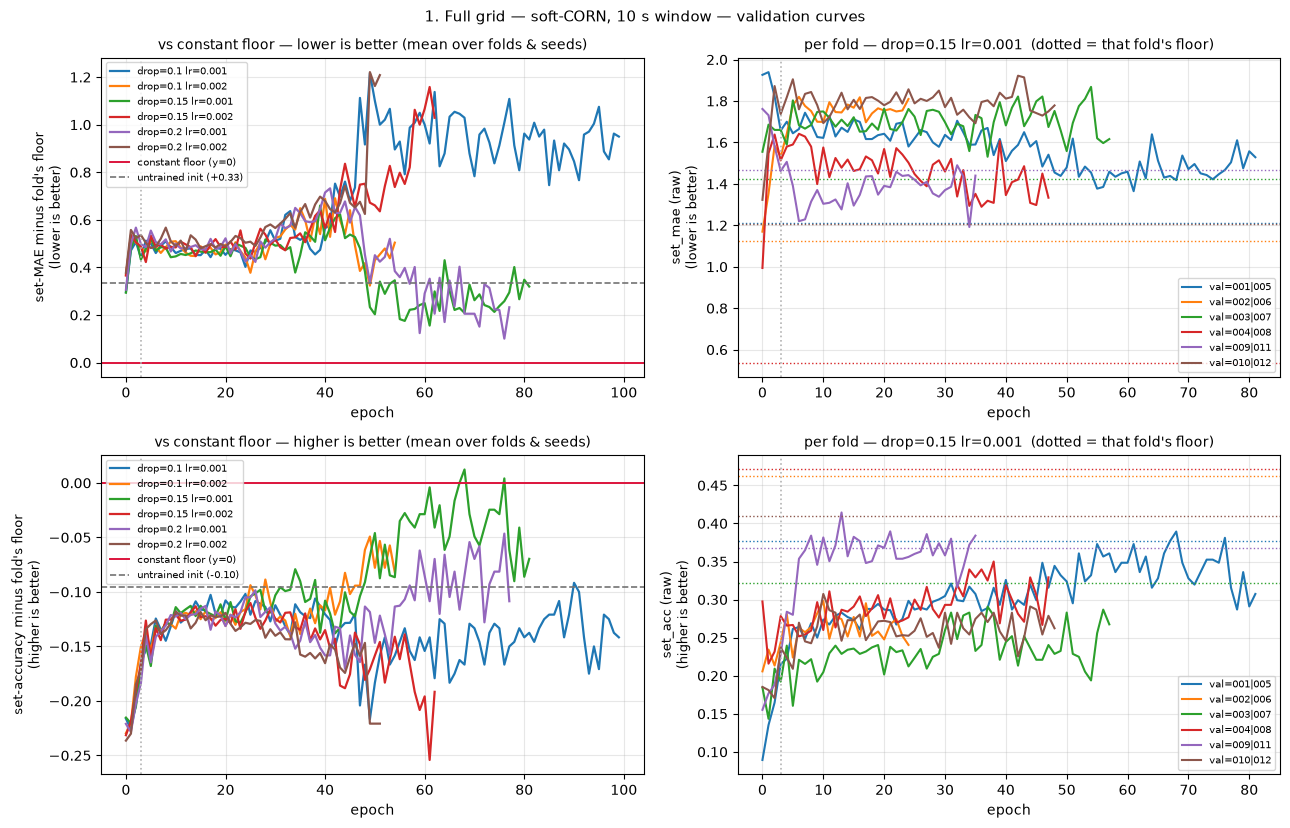

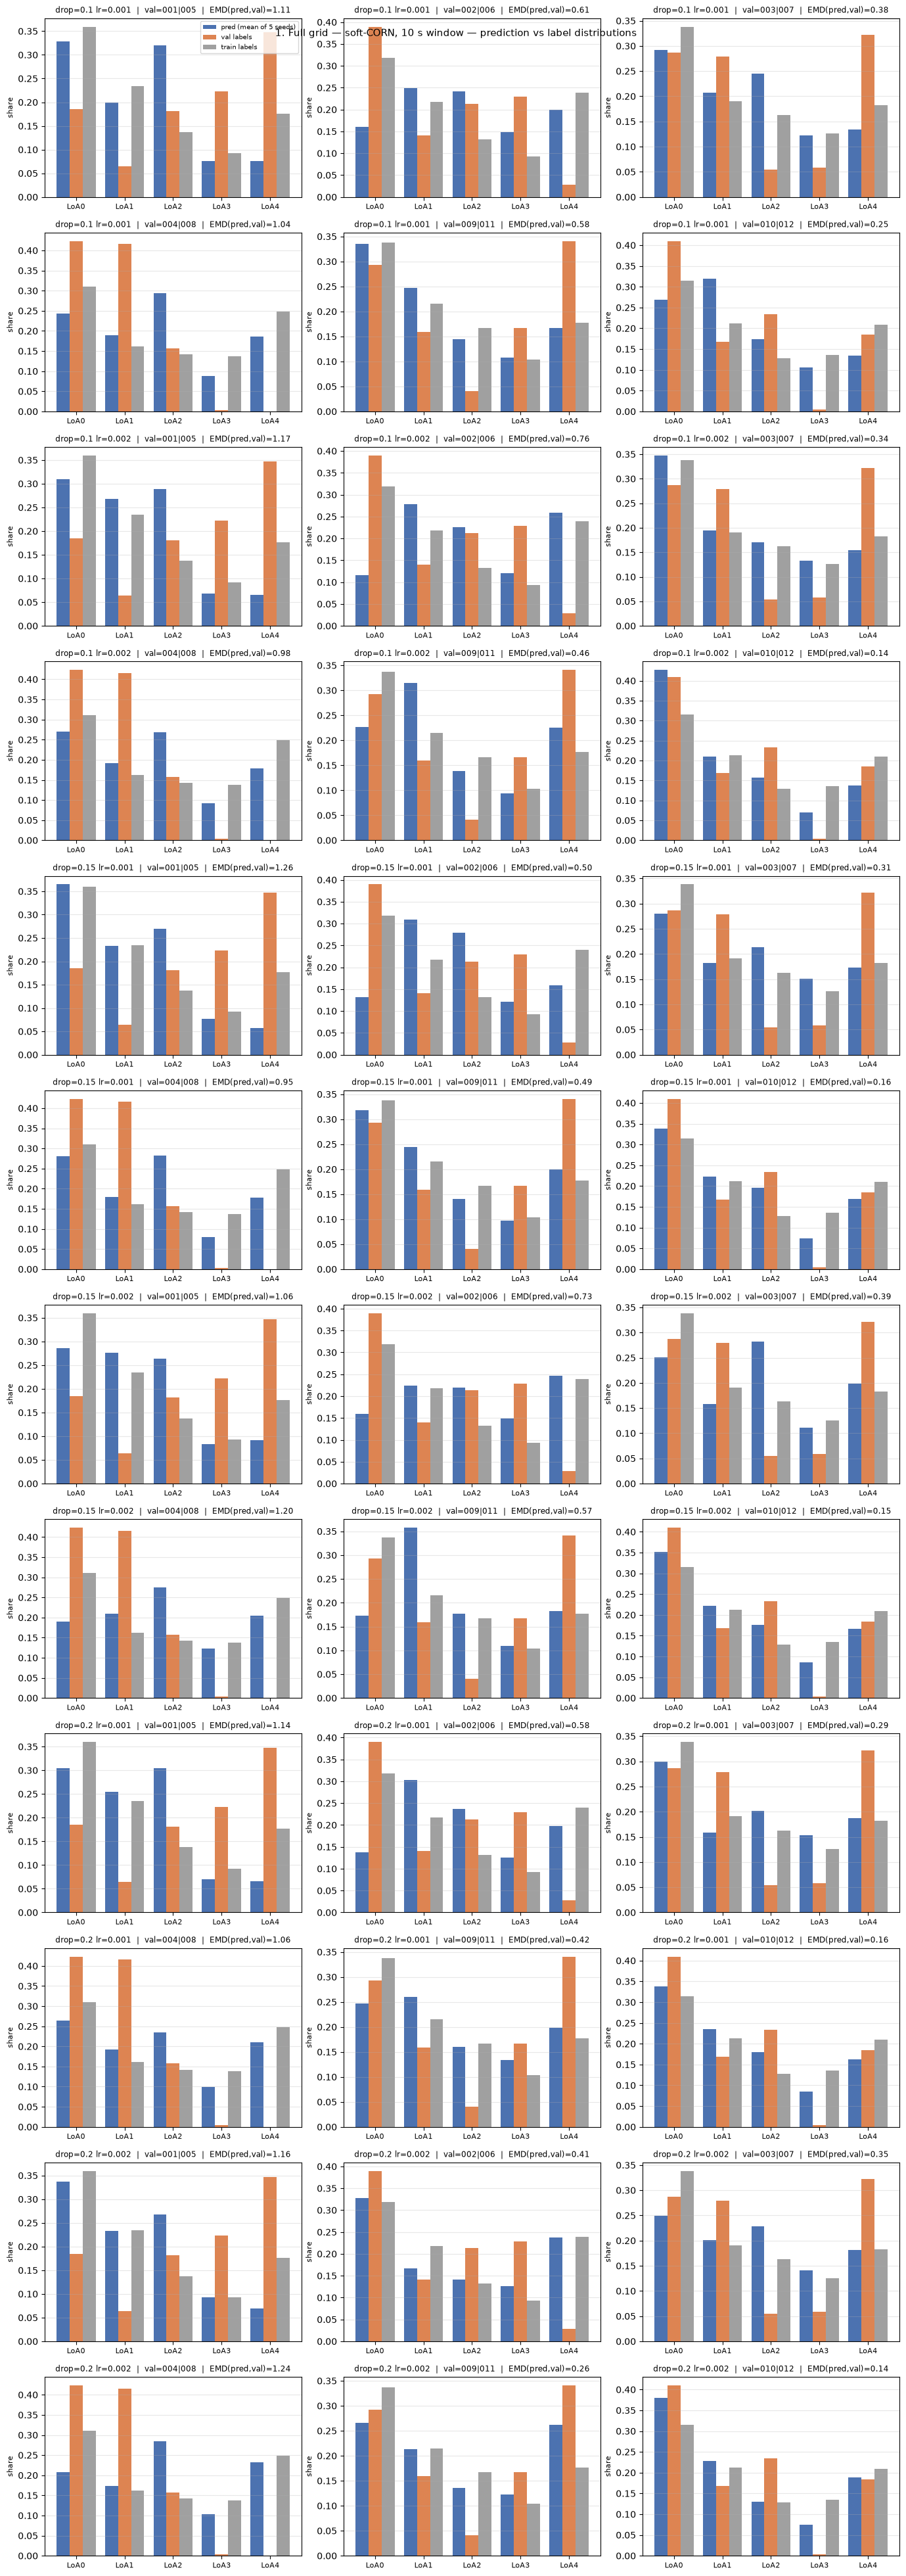

In [49]:
report_stage("corn_w10", "1. Full grid — soft-CORN, 10 s window")

---
## 2. Softmax / cross-entropy ablation — 10 s window

The ablation, not a candidate: the Laplace UQ layer refuses a non-CORN head, so CE
cannot be the deployed arm whatever it scores.

**Reading the CE-vs-CORN gap fairly.** The default decoder differs by head — argmax
(the mode) for softmax, the rank rule (the median) for CORN — and the median is optimal
for absolute error while the mode is optimal for accuracy. Comparing Table 1 across
sections 1 and 2 therefore measures *head and decoder together*. The cell after this one
holds the decoder fixed.

### 2. Softmax / CE ablation — 10 s window

180 runs | loss=ce | window=10.0s | 6 configuration(s) | 6 fold(s) | 5 seed(s)


**Table 1 — per configuration** (mean over folds and seeds)

,config,n_runs,set_mae,mae_sd,mae_se,mae_raw,set_acc,acc_sd,qwk,const_mae,const_acc,vs_const,beats_const,E_star
0,drop=0.1 lr=0.001,30,1.530,0.203,0.037,1.375,0.332,0.084,0.055,1.161,0.402,0.369,False,8.0
1,drop=0.1 lr=0.002,30,1.539,0.172,0.031,1.380,0.326,0.074,0.027,1.161,0.402,0.379,False,7.5
2,drop=0.15 lr=0.002,30,1.547,0.171,0.031,1.351,0.331,0.066,0.019,1.161,0.402,0.386,False,6.5
3,drop=0.15 lr=0.001,30,1.556,0.180,0.033,1.388,0.325,0.060,0.034,1.161,0.402,0.395,False,7.5
4,drop=0.2 lr=0.001,30,1.557,0.165,0.030,1.386,0.322,0.062,0.032,1.161,0.402,0.396,False,7.5
5,drop=0.2 lr=0.002,30,1.571,0.174,0.032,1.392,0.320,0.069,0.021,1.161,0.402,0.411,False,8.0


**Table 2 — per configuration x validation fold** (mean over seeds)

...

,config,vs_reference,n_pairs,delta,delta_sd,delta_se,t,worse_than_ref
0,drop=0.1 lr=0.002,drop=0.1 lr=0.001,30,0.009,0.093,0.017,0.560,True
1,drop=0.15 lr=0.002,drop=0.1 lr=0.001,30,0.017,0.080,0.015,1.188,True
2,drop=0.15 lr=0.001,drop=0.1 lr=0.001,30,0.026,0.093,0.017,1.550,True
3,drop=0.2 lr=0.001,drop=0.1 lr=0.001,30,0.027,0.101,0.018,1.457,True
4,drop=0.2 lr=0.002,drop=0.1 lr=0.001,30,0.041,0.088,0.016,2.578,True


**Table 7 — distribution distance** (earth-mover's distance, pred vs train vs val label shapes over LoA)

,config,val_pids,n_seeds,emd_pred_val,emd_pred_val_run,emd_pred_val_sd,emd_pred_train,emd_pred_train_run,emd_train_val,js_pred_val,js_train_val
0,drop=0.1 lr=0.001,001|005,5,1.202,1.202,0.095,0.242,0.270,0.992,0.406,0.317
1,drop=0.1 lr=0.001,002|006,5,0.451,0.476,0.118,0.167,0.192,0.363,0.331,0.325
2,drop=0.1 lr=0.001,003|007,5,0.309,0.418,0.241,0.073,0.322,0.300,0.218,0.227
3,drop=0.1 lr=0.001,004|008,5,0.921,0.923,0.377,0.189,0.396,1.110,0.416,0.480
4,drop=0.1 lr=0.001,009|011,5,0.467,0.470,0.156,0.280,0.309,0.536,0.139,0.241
5,drop=0.1 lr=0.001,010|012,5,0.147,0.204,0.049,0.290,0.291,0.327,0.212,0.273
6,drop=0.1 lr=0.002,001|005,5,1.189,1.189,0.068,0.233,0.266,0.992,0.383,0.317
7,drop=0.1 lr=0.002,002|006,5,0.495,0.521,0.102,0.222,0.276,0.363,0.326,0.325
8,drop=0.1 lr=0.002,003|007,5,0.347,0.425,0.214,0.070,0.240,0.300,0.246,0.227
9,drop=0.1 lr=0.002,004|008,5,0.953,0.953,0.136,0.180,0.223,1.110,0.412,0.480


**Table 7b — average distance over all runs** (per configuration, then across every run in the stage)

,config,n_runs,emd_pred_val,emd_pred_val_sd,emd_pred_val_se,emd_pred_train,emd_train_val,vs_shift,emd_run_gap,js_pred_val
0,drop=0.1 lr=0.001,30,0.616,0.391,0.071,0.297,0.605,0.011,0.033,0.304
1,drop=0.1 lr=0.002,30,0.640,0.367,0.067,0.298,0.605,0.035,0.034,0.317
2,drop=0.15 lr=0.001,30,0.647,0.458,0.084,0.298,0.605,0.043,0.033,0.308
3,drop=0.15 lr=0.002,30,0.658,0.388,0.071,0.299,0.605,0.053,0.028,0.304
4,drop=0.2 lr=0.002,30,0.673,0.395,0.072,0.323,0.605,0.069,0.023,0.315
5,drop=0.2 lr=0.001,30,0.684,0.433,0.079,0.305,0.605,0.080,0.025,0.335
6,ALL RUNS,180,0.653,0.401,0.030,0.303,0.605,0.048,0.029,0.314


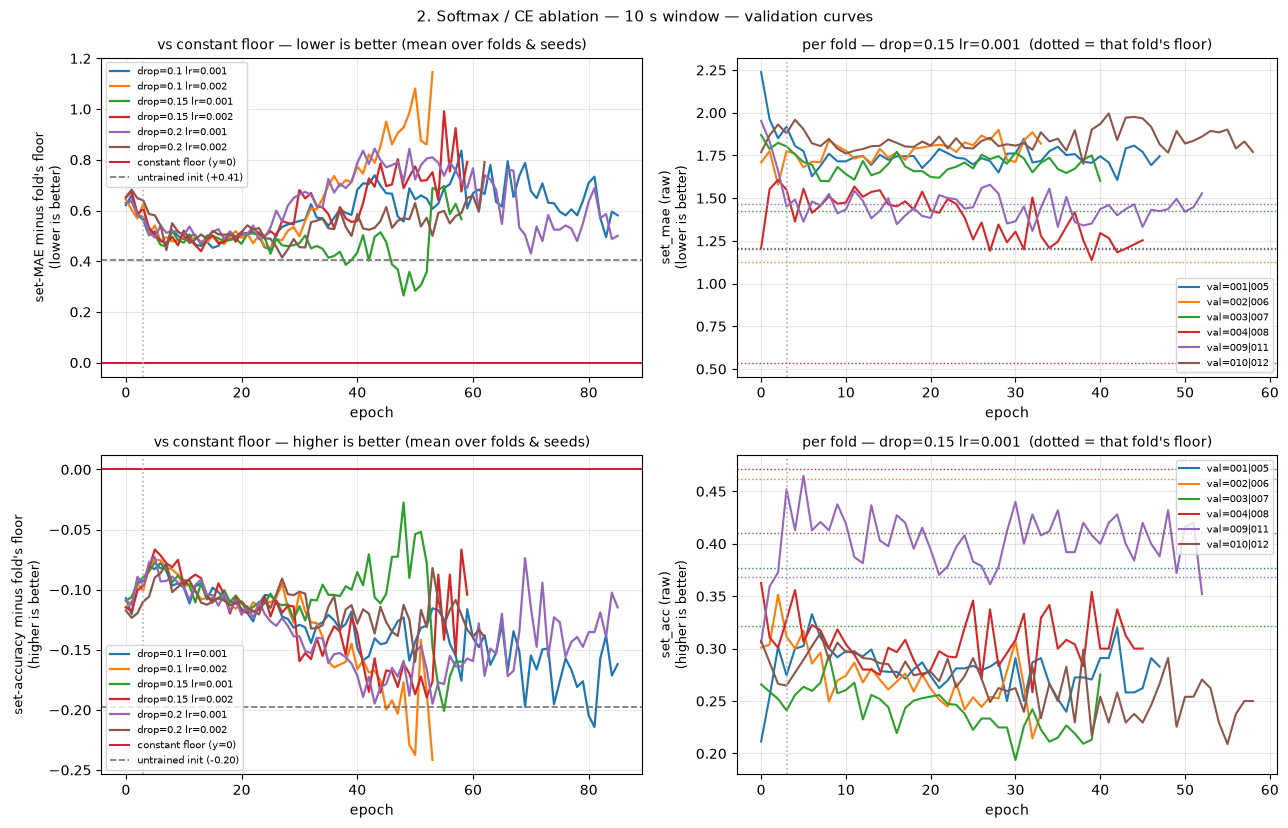

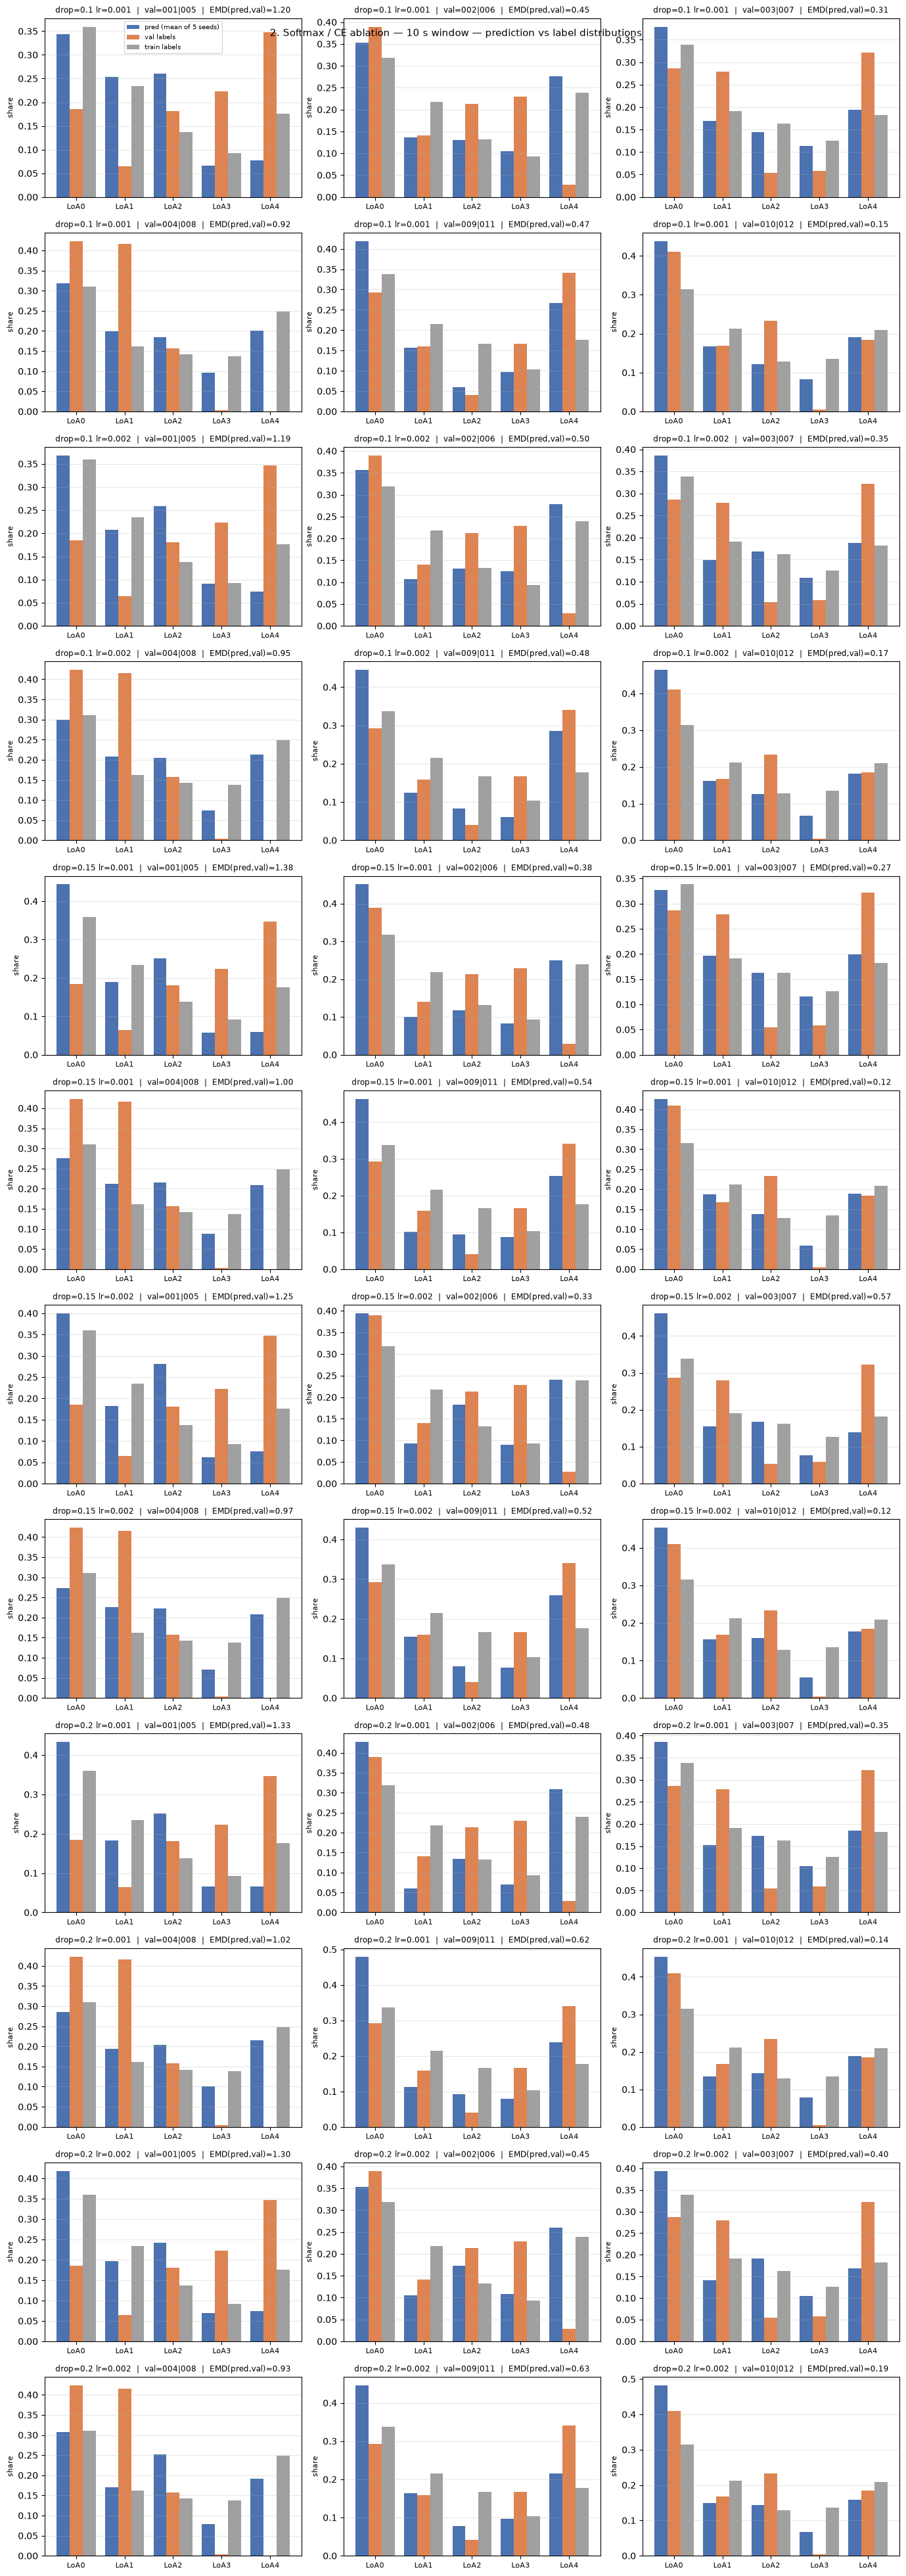

In [50]:
report_stage("ce_w10", "2. Softmax / CE ablation — 10 s window")

In [51]:
# CORN vs CE at a FIXED decoder — the controlled comparison.
rows = []
for name in ("corn_w10", "ce_w10"):
    d = load_stage(name)
    if d.empty or "mae_argmax" not in d:
        continue
    rows.append({"stage": name, "head": d["loss"].iloc[0] if "loss" in d else "?",
                 "n_runs": len(d),
                 "MAE @argmax (mode)": d["mae_argmax"].mean(),
                 "acc @argmax": d["acc_argmax"].mean(),
                 "MAE @median (rank rule)": d["mae_median"].mean(),
                 "acc @median": d["acc_median"].mean(),
                 "const floor": d["const_set_mae"].mean()})
if rows:
    t = pd.DataFrame(rows).round(3)
    display(Markdown("**Head vs decoder, disentangled** — compare *down* a column "
                     "(head effect at a fixed decoder), not across columns."))
    display(t)
    if len(t) == 2:
        for col in ("MAE @argmax (mode)", "MAE @median (rank rule)"):
            d = t[col].iloc[0] - t[col].iloc[1]
            better = t["head"].iloc[0] if d < 0 else t["head"].iloc[1]
            print(f"{col}: {better} better by {abs(d):.3f} MAE")
        print("\nIf both rows agree on which head wins, the advantage is the HEAD.")
        print("If they disagree, it was the decoder — and the design's metric is set-MAE.")
else:
    print("(need both corn_w10 and ce_w10 with per-decoder columns)")

**Head vs decoder, disentangled** — compare *down* a column (head effect at a fixed decoder), not across columns.

,stage,head,n_runs,MAE @argmax (mode),acc @argmax,MAE @median (rank rule),acc @median,const floor
0,corn_w10,corn,180,1.597,0.318,1.536,0.291,1.161
1,ce_w10,ce,180,1.574,0.326,1.536,0.310,1.161


MAE @argmax (mode): ce better by 0.023 MAE
MAE @median (rank rule): ce better by 0.000 MAE

If both rows agree on which head wins, the advantage is the HEAD.
If they disagree, it was the decoder — and the design's metric is set-MAE.


---
## 3. 5 s window — soft-CORN, winning configuration

Single configuration inherited from stage 1, so Tables 1, 5 and 6 have one row or are
empty. The format is identical so it reads against sections 1 and 4.

The model sees only the last 5 s of each 20 s label window. The label cadence is
unchanged — one segment is still one label — so this varies *input context*, not the
amount of supervision. `context_length` becomes 50.

### 3. 5 s window — soft-CORN

180 runs | loss=corn | window=5.0s | 6 configuration(s) | 6 fold(s) | 5 seed(s)


**Table 1 — per configuration** (mean over folds and seeds)

,config,n_runs,set_mae,mae_sd,mae_se,mae_raw,set_acc,acc_sd,qwk,const_mae,const_acc,vs_const,beats_const,E_star
0,drop=0.1 lr=0.001,30,1.512,0.176,0.032,1.250,0.285,0.064,0.040,1.161,0.402,0.351,False,6.5
1,drop=0.15 lr=0.002,30,1.536,0.153,0.028,1.283,0.291,0.062,0.030,1.161,0.402,0.375,False,7.0
2,drop=0.2 lr=0.002,30,1.537,0.166,0.030,1.284,0.298,0.067,0.055,1.161,0.402,0.376,False,7.5
3,drop=0.2 lr=0.001,30,1.552,0.162,0.030,1.270,0.287,0.059,0.018,1.161,0.402,0.391,False,5.0
4,drop=0.15 lr=0.001,30,1.557,0.174,0.032,1.267,0.270,0.070,0.004,1.161,0.402,0.396,False,7.0
5,drop=0.1 lr=0.002,30,1.558,0.139,0.025,1.304,0.275,0.059,0.021,1.161,0.402,0.397,False,6.0


**Table 2 — per configuration x validation fold** (mean over seeds)

...

,config,vs_reference,n_pairs,delta,delta_sd,delta_se,t,worse_than_ref
0,drop=0.15 lr=0.002,drop=0.1 lr=0.001,30,0.024,0.072,0.013,1.835,True
1,drop=0.2 lr=0.002,drop=0.1 lr=0.001,30,0.025,0.085,0.015,1.599,True
2,drop=0.2 lr=0.001,drop=0.1 lr=0.001,30,0.040,0.083,0.015,2.667,True
3,drop=0.15 lr=0.001,drop=0.1 lr=0.001,30,0.046,0.063,0.012,3.946,True
4,drop=0.1 lr=0.002,drop=0.1 lr=0.001,30,0.046,0.088,0.016,2.890,True


**Table 7 — distribution distance** (earth-mover's distance, pred vs train vs val label shapes over LoA)

,config,val_pids,n_seeds,emd_pred_val,emd_pred_val_run,emd_pred_val_sd,emd_pred_train,emd_pred_train_run,emd_train_val,js_pred_val,js_train_val
0,drop=0.1 lr=0.001,001|005,5,1.149,1.149,0.178,0.271,0.331,0.992,0.402,0.317
1,drop=0.1 lr=0.001,002|006,5,0.704,0.704,0.223,0.397,0.445,0.363,0.355,0.325
2,drop=0.1 lr=0.001,003|007,5,0.324,0.372,0.172,0.322,0.323,0.300,0.287,0.227
3,drop=0.1 lr=0.001,004|008,5,1.073,1.073,0.177,0.352,0.378,1.110,0.438,0.480
4,drop=0.1 lr=0.001,009|011,5,0.319,0.411,0.122,0.217,0.243,0.536,0.189,0.241
5,drop=0.1 lr=0.001,010|012,5,0.166,0.185,0.074,0.264,0.330,0.327,0.218,0.273
6,drop=0.1 lr=0.002,001|005,5,1.234,1.234,0.305,0.365,0.502,0.992,0.452,0.317
7,drop=0.1 lr=0.002,002|006,5,0.767,0.789,0.341,0.415,0.501,0.363,0.398,0.325
8,drop=0.1 lr=0.002,003|007,5,0.317,0.345,0.057,0.121,0.173,0.300,0.274,0.227
9,drop=0.1 lr=0.002,004|008,5,1.104,1.104,0.108,0.239,0.286,1.110,0.451,0.480


**Table 7b — average distance over all runs** (per configuration, then across every run in the stage)

,config,n_runs,emd_pred_val,emd_pred_val_sd,emd_pred_val_se,emd_pred_train,emd_train_val,vs_shift,emd_run_gap,js_pred_val
0,drop=0.1 lr=0.001,30,0.649,0.397,0.072,0.342,0.605,0.044,0.026,0.331
1,drop=0.15 lr=0.002,30,0.669,0.382,0.070,0.338,0.605,0.064,0.050,0.333
2,drop=0.2 lr=0.001,30,0.675,0.408,0.074,0.317,0.605,0.071,0.033,0.333
3,drop=0.2 lr=0.002,30,0.686,0.437,0.080,0.299,0.605,0.082,0.010,0.334
4,drop=0.1 lr=0.002,30,0.716,0.409,0.075,0.339,0.605,0.112,0.033,0.371
5,drop=0.15 lr=0.001,30,0.761,0.403,0.074,0.358,0.605,0.156,0.048,0.356
6,ALL RUNS,180,0.693,0.402,0.030,0.332,0.605,0.088,0.033,0.343


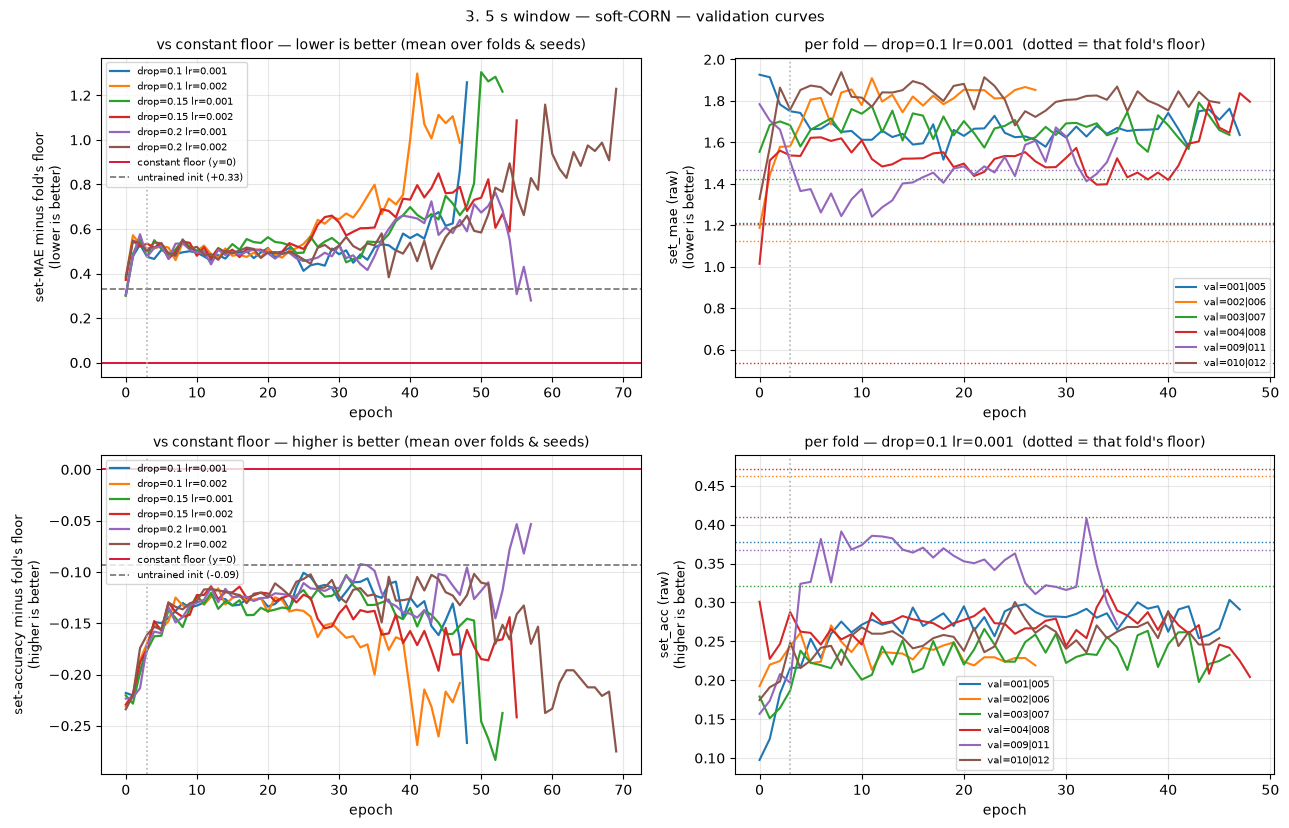

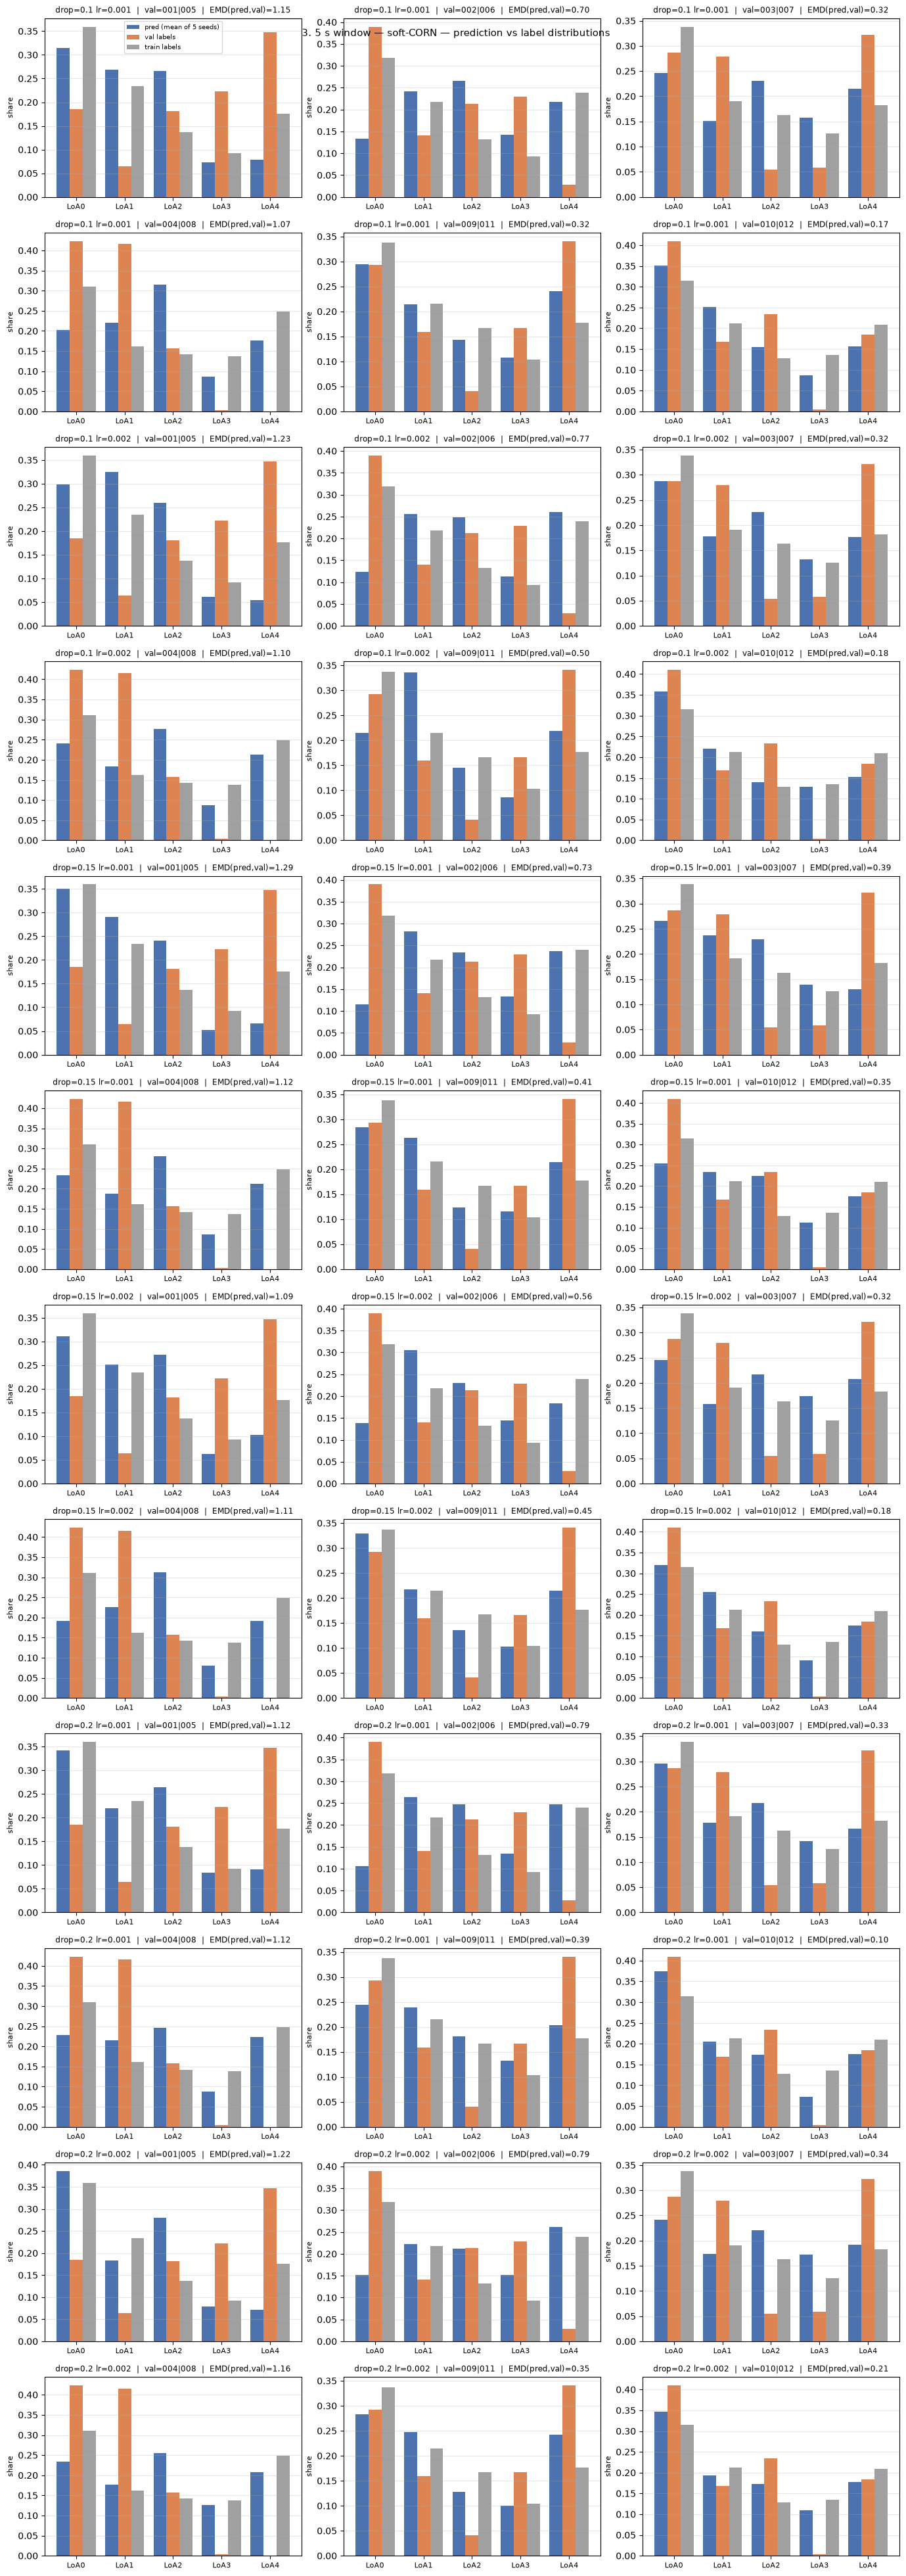

In [52]:
report_stage("corn_w5", "3. 5 s window — soft-CORN")

---
## 4. 20 s window — soft-CORN, winning configuration

The full label window; `context_length` becomes 200. Same single-configuration format
as section 3.

### 4. 20 s window — soft-CORN

180 runs | loss=corn | window=20.0s | 6 configuration(s) | 6 fold(s) | 5 seed(s)


**Table 1 — per configuration** (mean over folds and seeds)

,config,n_runs,set_mae,mae_sd,mae_se,mae_raw,set_acc,acc_sd,qwk,const_mae,const_acc,vs_const,beats_const,E_star
0,drop=0.15 lr=0.001,30,1.509,0.179,0.033,1.240,0.285,0.066,0.047,1.161,0.402,0.348,False,7.0
1,drop=0.2 lr=0.002,30,1.510,0.181,0.033,1.254,0.302,0.069,0.037,1.161,0.402,0.350,False,6.0
2,drop=0.15 lr=0.002,30,1.512,0.166,0.030,1.290,0.302,0.058,0.063,1.161,0.402,0.351,False,7.0
3,drop=0.2 lr=0.001,30,1.514,0.193,0.035,1.255,0.286,0.069,0.058,1.161,0.402,0.353,False,7.0
4,drop=0.1 lr=0.001,30,1.517,0.198,0.036,1.254,0.301,0.072,0.059,1.161,0.402,0.356,False,6.5
5,drop=0.1 lr=0.002,30,1.524,0.154,0.028,1.270,0.301,0.060,0.057,1.161,0.402,0.363,False,6.0


**Table 2 — per configuration x validation fold** (mean over seeds)

...

,config,vs_reference,n_pairs,delta,delta_sd,delta_se,t,worse_than_ref
0,drop=0.2 lr=0.002,drop=0.15 lr=0.001,30,0.002,0.086,0.016,0.096,True
1,drop=0.15 lr=0.002,drop=0.15 lr=0.001,30,0.003,0.109,0.020,0.150,True
2,drop=0.2 lr=0.001,drop=0.15 lr=0.001,30,0.005,0.069,0.013,0.382,True
3,drop=0.1 lr=0.001,drop=0.15 lr=0.001,30,0.008,0.075,0.014,0.550,True
4,drop=0.1 lr=0.002,drop=0.15 lr=0.001,30,0.015,0.108,0.020,0.772,True


**Table 7 — distribution distance** (earth-mover's distance, pred vs train vs val label shapes over LoA)

,config,val_pids,n_seeds,emd_pred_val,emd_pred_val_run,emd_pred_val_sd,emd_pred_train,emd_pred_train_run,emd_train_val,js_pred_val,js_train_val
0,drop=0.1 lr=0.001,001|005,5,1.140,1.140,0.104,0.357,0.369,0.992,0.429,0.317
1,drop=0.1 lr=0.001,002|006,5,0.601,0.679,0.202,0.404,0.514,0.363,0.375,0.325
2,drop=0.1 lr=0.001,003|007,5,0.302,0.339,0.066,0.109,0.173,0.300,0.252,0.227
3,drop=0.1 lr=0.001,004|008,5,0.970,0.970,0.273,0.212,0.305,1.110,0.417,0.480
4,drop=0.1 lr=0.001,009|011,5,0.477,0.485,0.231,0.152,0.258,0.536,0.183,0.241
5,drop=0.1 lr=0.001,010|012,5,0.223,0.244,0.202,0.209,0.314,0.327,0.226,0.273
6,drop=0.1 lr=0.002,001|005,5,1.426,1.426,0.190,0.435,0.456,0.992,0.488,0.317
7,drop=0.1 lr=0.002,002|006,5,0.744,0.834,0.496,0.392,0.630,0.363,0.362,0.325
8,drop=0.1 lr=0.002,003|007,5,0.281,0.357,0.079,0.098,0.258,0.300,0.220,0.227
9,drop=0.1 lr=0.002,004|008,5,1.218,1.218,0.359,0.213,0.357,1.110,0.463,0.480


**Table 7b — average distance over all runs** (per configuration, then across every run in the stage)

,config,n_runs,emd_pred_val,emd_pred_val_sd,emd_pred_val_se,emd_pred_train,emd_train_val,vs_shift,emd_run_gap,js_pred_val
0,drop=0.1 lr=0.001,30,0.643,0.374,0.068,0.322,0.605,0.038,0.024,0.326
1,drop=0.2 lr=0.002,30,0.663,0.372,0.068,0.321,0.605,0.058,0.032,0.328
2,drop=0.2 lr=0.001,30,0.693,0.416,0.076,0.354,0.605,0.088,0.056,0.343
3,drop=0.15 lr=0.001,30,0.701,0.403,0.074,0.321,0.605,0.096,0.034,0.343
4,drop=0.15 lr=0.002,30,0.720,0.419,0.076,0.321,0.605,0.115,0.045,0.338
5,drop=0.1 lr=0.002,30,0.747,0.527,0.096,0.393,0.605,0.143,0.050,0.344
6,ALL RUNS,180,0.694,0.417,0.031,0.339,0.605,0.090,0.040,0.337


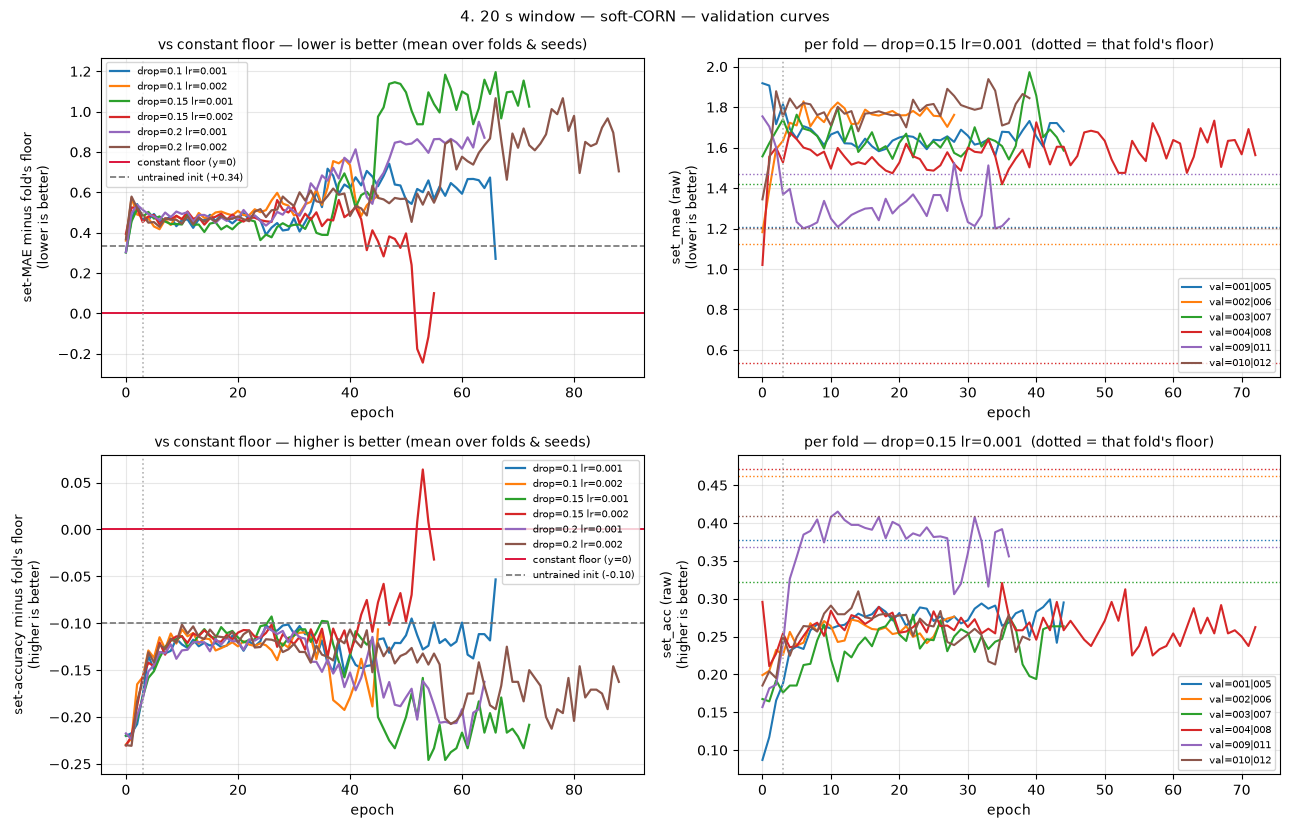

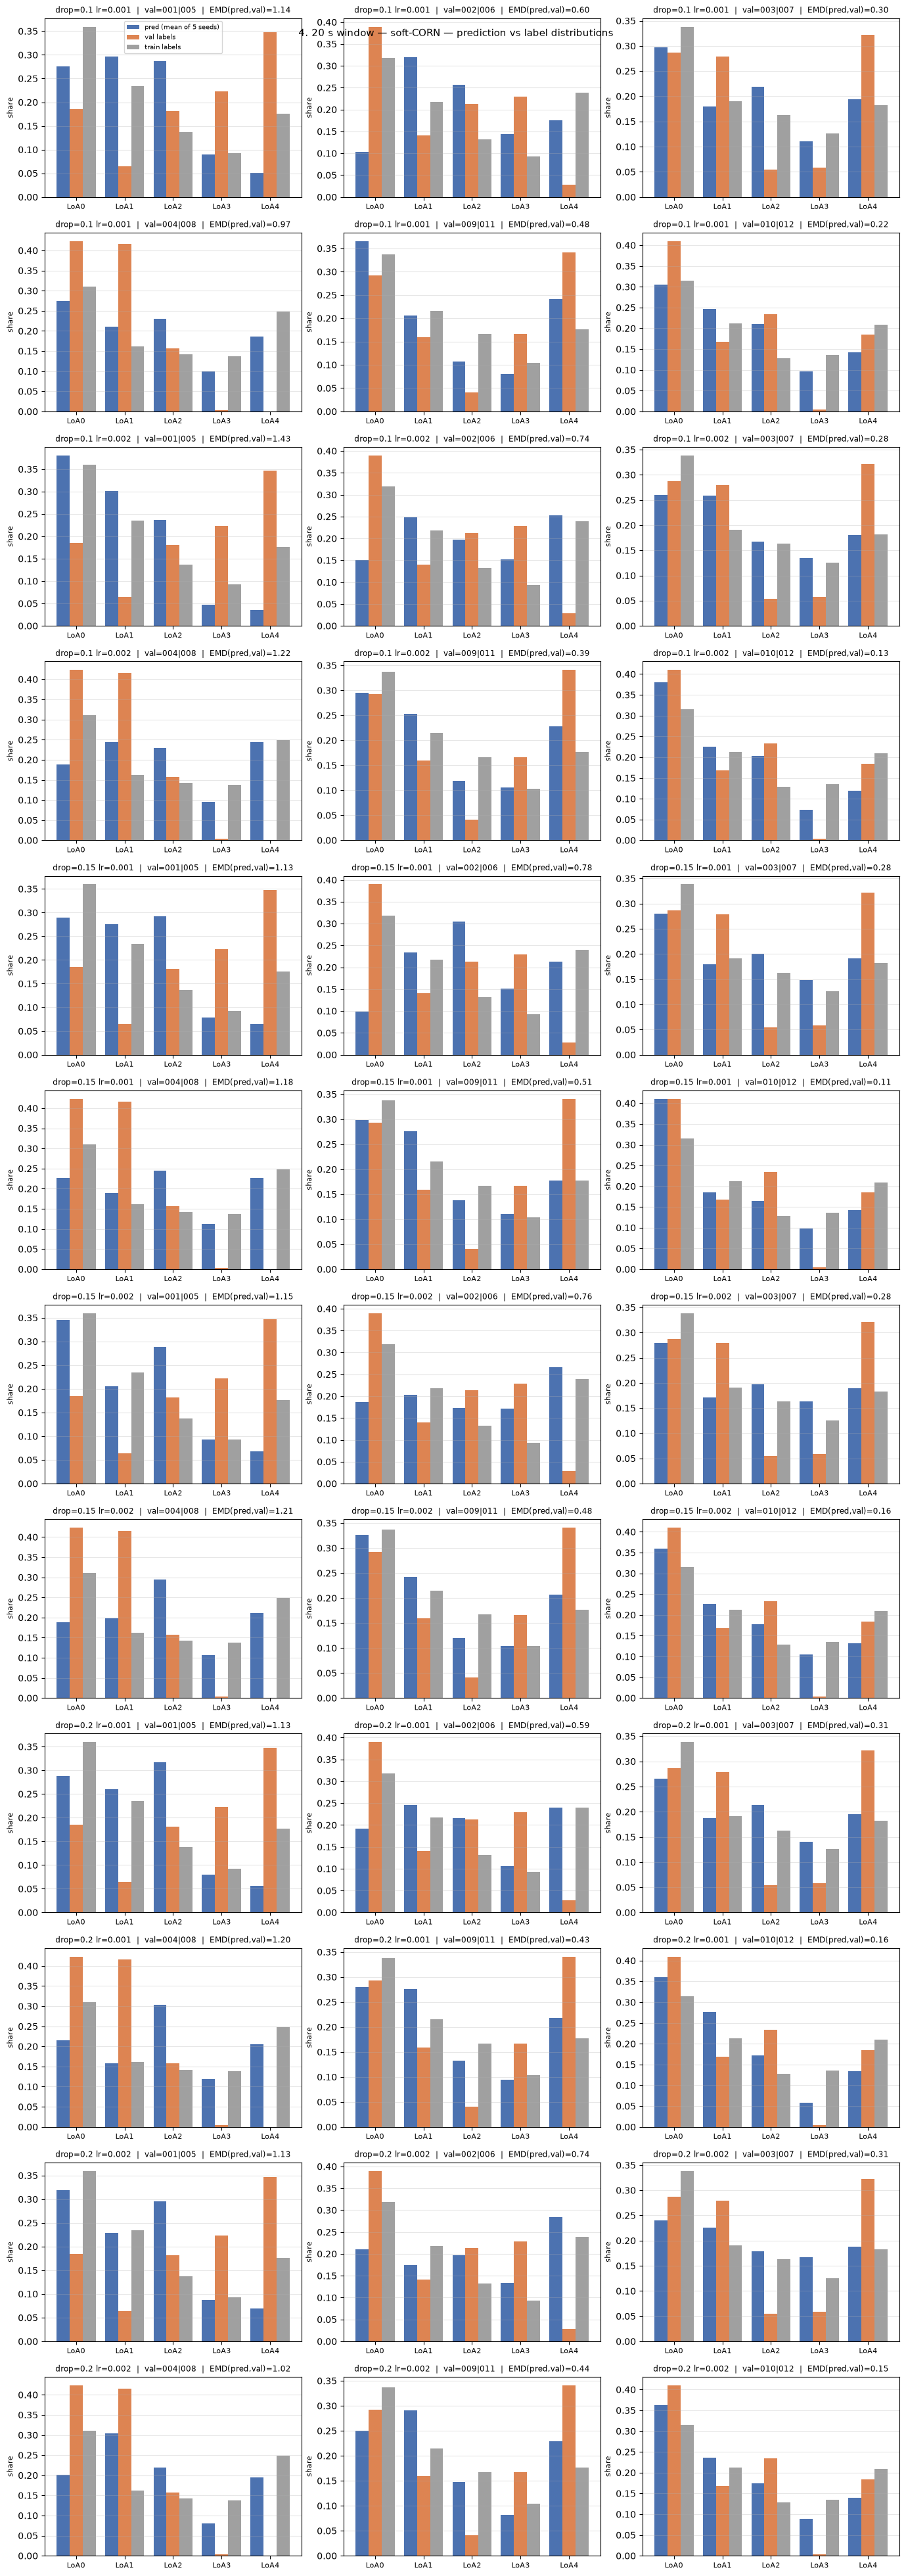

In [53]:
report_stage("corn_w20", "4. 20 s window — soft-CORN")

---
## Cross-stage roll-up

The window comparison (stages 1, 3, 4 — same loss and configuration, different input
context) and the head comparison (1 vs 2), in one table. The spread across windows is
checked against the seed noise before it is read as a result.

In [54]:
rows = []
for name, title in STAGES:
    d = load_stage(name)
    if d.empty:
        continue
    best = table_per_config(d).iloc[0]          # sorted by set_mae
    pr = per_run_curves(name)
    init = float(pr["init_mae"].mean()) if not pr.empty and pr["init_mae"].notna().any() else np.nan
    # Distribution distance averaged over EVERY run in the stage (Table 7b's
    # ALL RUNS row), so the stages compare on one distributional number too.
    prd = per_run_distances(d)
    emd_pv = float(prd["emd_pred_val"].mean()) if not prd.empty else np.nan
    emd_pv_se = (float(prd["emd_pred_val"].std(ddof=1)) / np.sqrt(len(prd))
                 if len(prd) > 1 else np.nan)
    emd_tv = float(prd["emd_train_val"].mean()) if not prd.empty else np.nan
    rows.append({"stage": name,
                 "loss": d["loss"].iloc[0] if "loss" in d else "?",
                 "window_s": d["window_seconds"].iloc[0] if "window_seconds" in d else np.nan,
                 "best_config": best["config"], "n_runs": int(best["n_runs"]),
                 "init_mae": init,
                 "set_mae": best["set_mae"], "mae_se": best["mae_se"],
                 "set_acc": best["set_acc"], "const_mae": best["const_mae"],
                 "vs_const": best["vs_const"], "E_star": best["E_star"],
                 "emd_pred_val": emd_pv, "emd_se": emd_pv_se, "emd_train_val": emd_tv})
if rows:
    roll = pd.DataFrame(rows).round(3)
    display(roll)
    corn = roll[roll["loss"] == "corn"]
    if len(corn) > 1:
        b = corn.loc[corn["set_mae"].idxmin()]
        spread = float(corn["set_mae"].max() - corn["set_mae"].min())
        se = float(corn["mae_se"].mean())
        print(f"\nBest CORN window: {b['window_s']:g}s (set-MAE {b['set_mae']:.3f})")
        print(f"Spread across windows: {spread:.3f} vs mean SE {se:.3f} -> "
              f"{'MEANINGFUL' if spread > 2 * se else 'WITHIN NOISE, do not over-read'}")
        if corn["emd_pred_val"].notna().all():
            be = corn.loc[corn["emd_pred_val"].idxmin()]
            espread = float(corn["emd_pred_val"].max() - corn["emd_pred_val"].min())
            ese = float(corn["emd_se"].mean())
            print(f"\nBest CORN window on EMD(pred,val): {be['window_s']:g}s "
                  f"({be['emd_pred_val']:.3f} LoA)")
            print(f"Spread across windows: {espread:.3f} vs mean SE {ese:.3f} -> "
                  f"{'MEANINGFUL' if espread > 2 * ese else 'WITHIN NOISE, do not over-read'}")
            print("Agrees with the set-MAE ranking above."
                  if be["stage"] == b["stage"] else
                  "DISAGREES with the set-MAE ranking above — set-MAE is the design's "
                  "selection metric; EMD describes the prediction SHAPE, so a split "
                  "means the better-shaped model is not the more accurate one.")
    if (roll["vs_const"] > 0).all():
        print("\nNOTE: no stage beats its constant floor. The window and head comparisons "
              "are then between models that all lose to 'always predict one level'. That "
              "is a property of the task on this cohort (driver identity is worth ~4x more "
              "MAE than the task), not necessarily of the runs — but it means the "
              "population model should be read as an INITIALIZATION for personalization, "
              "not as a result in itself. Check Table 4 in each section: if the models do "
              "beat their untrained init, they ARE learning, just not something that "
              "transfers across drivers.")
    if roll["emd_pred_val"].notna().all() and (roll["emd_pred_val"] > roll["emd_train_val"]).all():
        print("\nNOTE: in every stage the mean EMD(pred, val) exceeds EMD(train-labels, val-labels) "
              "— the predictions are further from the held-out label distribution than the "
              "TRAINING labels already are. The models are not merely inheriting the "
              "population shift between driver sets; they are adding distributional error "
              "on top of it.")
else:
    print("(no stages have run yet)")

,stage,loss,window_s,best_config,n_runs,init_mae,set_mae,mae_se,set_acc,const_mae,vs_const,E_star,emd_pred_val,emd_se,emd_train_val
0,corn_w10,corn,10.0,drop=0.15 lr=0.001,30,1.485,1.520,0.031,0.296,1.161,0.359,5.5,0.678,0.029,0.605
1,ce_w10,ce,10.0,drop=0.1 lr=0.001,30,1.551,1.530,0.037,0.332,1.161,0.369,8.0,0.653,0.030,0.605
2,corn_w5,corn,5.0,drop=0.1 lr=0.001,30,1.483,1.512,0.032,0.285,1.161,0.351,6.5,0.693,0.030,0.605
3,corn_w20,corn,20.0,drop=0.15 lr=0.001,30,1.487,1.509,0.033,0.285,1.161,0.348,7.0,0.694,0.031,0.605



Best CORN window: 20s (set-MAE 1.509)
Spread across windows: 0.011 vs mean SE 0.032 -> WITHIN NOISE, do not over-read

Best CORN window on EMD(pred,val): 10s (0.678 LoA)
Spread across windows: 0.016 vs mean SE 0.030 -> WITHIN NOISE, do not over-read
DISAGREES with the set-MAE ranking above — set-MAE is the design's selection metric; EMD describes the prediction SHAPE, so a split means the better-shaped model is not the more accurate one.

NOTE: no stage beats its constant floor. The window and head comparisons are then between models that all lose to 'always predict one level'. That is a property of the task on this cohort (driver identity is worth ~4x more MAE than the task), not necessarily of the runs — but it means the population model should be read as an INITIALIZATION for personalization, not as a result in itself. Check Table 4 in each section: if the models do beat their untrained init, they ARE learning, just not something that transfers across drivers.

NOTE: in every stage